# Revised Heeren/Gruhler Typology Assignment

This notebook implements the assignment hierarchy from `Heeren_typology_assignment_working_template.csv` as the methodological source of truth.

The assignment cascade is ordered: specific Gruhler typologies first, then CSV-defined Gruhler candidate averages, then CSV-defined broader Gruhler averages, then Ortlepp MFH period fallbacks, then the Ortlepp general MFH average. Typologies 137-138 are excluded from the standard cascade because Hamburg has no usable construction-system field for this distinction.

In [1]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data/raw/hamburg_buildings_clean.gpkg").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root from current working directory. "
        f"Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root()

HAMBURG_BUILDINGS_PATH = PROJECT_ROOT / "data/raw/hamburg_buildings_clean.gpkg"
HEEREN_PATH = PROJECT_ROOT / "data/raw/Heeren_Germany Only.csv"
TYPOLOGY_RULES_PATH = PROJECT_ROOT / "data/raw/Attachment 1_Heeren_typology_assignment_working_template - Heeren_typology_assignment_working_template.csv"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
MAP_DIR = PROJECT_ROOT / "results/maps"

OUTPUT_BUILDINGS_PATH = PROCESSED_DIR / "hamburg_buildings_with_heeren_material_estimates.gpkg"
OUTPUT_RESIDENTIAL_PATH = PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg"
OUTPUT_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_assignment_level_summary.csv"
OUTPUT_CONFIDENCE_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_confidence_tier_summary.csv"
OUTPUT_QUALITY_FLAGS_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_quality_flags_summary.csv"
OUTPUT_RULE_LIMITATIONS_PATH = PROCESSED_DIR / "hamburg_heeren_typology_rule_limitations.csv"
OUTPUT_COMPARISON_LAYER_COVERAGE_PATH = PROCESSED_DIR / "hamburg_comparison_layer_coverage_summary.csv"
OUTPUT_UNASSIGNED_REASON_SUMMARY_PATH = PROCESSED_DIR / "hamburg_unassigned_reason_summary.csv"
OUTPUT_IOER_QA_PATH = PROCESSED_DIR / "hamburg_ioer_reference_qa.csv"
OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH = PROCESSED_DIR / "hamburg_ioer_benchmark_material_group_summary.csv"
OUTPUT_MATERIAL_FRACTION_SUMMARY_PATH = PROCESSED_DIR / "hamburg_material_fraction_comparison_summary.csv"
OUTPUT_MATERIAL_FRACTION_COMMON_SCOPE_SUMMARY_PATH = PROCESSED_DIR / "hamburg_material_fraction_common_scope_comparison_summary.csv"
MATERIAL_FRACTION_COMPARISON_CHART_PATH = MAP_DIR / "hamburg_material_fraction_comparison.png"
MATERIAL_FRACTION_COMMON_SCOPE_CHART_PATH = MAP_DIR / "hamburg_material_fraction_common_scope_comparison.png"
TYPOLOGY_SPATIAL_DISTRIBUTION_MAP_PATH = MAP_DIR / "hamburg_typology_spatial_distribution_map.png"

IOER_EFH_MATERIAL_PATH = PROJECT_ROOT / "data/raw/IÖR_EFH_Hamburg.csv"
IOER_EFH_VOLUME_PATH = PROJECT_ROOT / "data/raw/IÖR_EFH_Hamburg_building volume.csv"
IOER_MFH_MATERIAL_PATH = PROJECT_ROOT / "data/raw/IÖR_MFH_Hamburg.csv"
IOER_MFH_VOLUME_PATH = PROJECT_ROOT / "data/raw/IÖR_MFH_Hamburg_building volume.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 180)

MAIN_RESIDENTIAL_FUNCTION_CODES = {
    1010: "Wohnhaus",
    1020: "Wohnheim",
    1100: "Gemischt genutztes Gebaeude mit Wohnen",
    1110: "Wohngebaeude mit Gemeinbedarf",
    1120: "Wohngebaeude mit Handel und Dienstleistungen",
    1130: "Wohngebaeude mit Gewerbe und Industrie",
    1210: "Land- und forstwirtschaftliches Wohngebaeude",
    1220: "Land- und forstwirtschaftliches Wohn- und Betriebsgebaeude",
}

EXCLUDED_RESIDENTIAL_RELATED_CODES = {
    1311: "Ferienhaus",
    1312: "Wochenendhaus",
    1313: "Gartenhaus",
}

MAIN_RESIDENTIAL_CODE_SET = set(MAIN_RESIDENTIAL_FUNCTION_CODES)
EXCLUDED_RESIDENTIAL_RELATED_CODE_SET = set(EXCLUDED_RESIDENTIAL_RELATED_CODES)
CURRENT_YEAR_MAX = 2026
ATTIC_STOREY_FACTOR_ATTIC_POSSIBLE_FOR_GFA = 1.0
DETACHED_SMALL_PITCHED_ROOF_CODES_FOR_ID_115 = {"3100", "3200", "3300", "3500"}

BAUWEISE_GROUP_MAP = {
    "1100": "detached_sfh",
    "2100": "semi_detached_sfh",
    "2200": "row_terraced_grouped_sfh",
    "2300": "row_terraced_grouped_sfh",
    "2400": "row_terraced_grouped_sfh",
    "1200": "mfh",
    "2500": "mfh",
}

ROOF_GROUP_CSV_MAP = {
    "1000": "no_attic_proxy",
    "2100": "no_attic_proxy",
    "3100": "attic_possible",
    "3200": "attic_possible",
    "3300": "attic_possible",
    "3400": "attic_possible",
    "3500": "attic_possible",
    "9999": "unknown_roof",
}

MATERIAL_COLUMNS = [
    "copper", "aluminum", "unspecified_metal",
    "wood", "paper_cardboard", "straw",
    "concrete", "cement", "aggregates", "brick", "mortar_plaster",
    "mineral_fill", "plaster_board_gypsum", "adobe",
    "asphalt", "bitumen", "natural_stone", "cement_asbestos", "clay",
    "siding_unspecified", "ceramics", "glass", "plastics", "polystyrene",
    "PVC", "lineoleum", "carpet", "heraklith", "mineral_wool",
    "insulation_unspecified", "other_unspecified_material",
]

ASSIGNED_LEVEL_PREFIXES = ("1_", "2_", "3_", "4_", "5_")

CONFIDENCE_TIER_BY_ASSIGNMENT_LEVEL = {
    "1_gruhler_specific_typology": "A_direct",
    "2_gruhler_candidate_average": "C_fallback",
    "3_gruhler_fallback_average": "C_fallback",
    "4_ortlepp_period_mfh_fallback": "C_fallback",
    "5_ortlepp_general_mfh_average": "C_fallback",
    "not_residential_no_material_intensity": "D_unassigned",
    "unresolved_no_material_intensity": "D_unassigned",
}

CONFIDENCE_TIER_LABELS = {
    "A_direct": "A - Direct match",
    "B_representative": "B - Representative match",
    "C_fallback": "C - Fallback estimate",
    "D_unassigned": "D - Unassigned",
}

PRIMARY_CONFIDENCE_TIER_ORDER = ["A_direct", "B_representative", "C_fallback", "D_unassigned"]

In [2]:
def clean_string_series(series):
    return series.astype("string").str.strip().replace({"": pd.NA, "NULL": pd.NA, "NA": pd.NA})


def normalize_code(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if text == "" or text.upper() in {"NULL", "NA"}:
        return pd.NA
    numeric = pd.to_numeric(text, errors="coerce")
    if pd.notna(numeric) and float(numeric).is_integer():
        return str(int(numeric))
    return text


def clean_baujahr(value):
    if pd.isna(value):
        return pd.Series({"construction_year_clean": pd.NA, "construction_year_status": "missing"})

    text = str(value).strip()
    if text == "" or text.upper() in {"NULL", "NA"}:
        return pd.Series({"construction_year_clean": pd.NA, "construction_year_status": "missing"})

    years = [int(year) for year in re.findall(r"\d{4}", text)]
    if not years:
        return pd.Series({"construction_year_clean": pd.NA, "construction_year_status": "missing"})

    plausible_years = [year for year in years if 1500 < year <= CURRENT_YEAR_MAX]

    if years == [1500] or (not plausible_years and 1500 in years):
        return pd.Series({"construction_year_clean": pd.NA, "construction_year_status": "invalid_placeholder_1500"})

    if len(plausible_years) == 1 and len(years) == 1:
        return pd.Series({"construction_year_clean": plausible_years[0], "construction_year_status": "single_year"})

    if plausible_years:
        return pd.Series({
            "construction_year_clean": min(plausible_years),
            "construction_year_status": "multiple_years_earliest_used" if len(years) > 1 else "single_year",
        })

    return pd.Series({"construction_year_clean": pd.NA, "construction_year_status": "invalid_or_unusable"})


def construction_year_source(status):
    if pd.isna(status):
        return "unknown"
    status_text = str(status)
    if "estimated" in status_text.lower() or "imputed" in status_text.lower():
        return "estimated"
    if status_text == "single_year":
        return "observed_cleaned"
    if status_text == "multiple_years_earliest_used":
        return "observed_multiple_years_earliest_used"
    if status_text in {"missing", "invalid_placeholder_1500", "invalid_or_unusable"}:
        return "unavailable"
    return status_text


def valid_integer(value):
    numeric = pd.to_numeric(value, errors="coerce")
    return pd.notna(numeric) and float(numeric).is_integer()


def year_between(year, start=None, end=None):
    if pd.isna(year):
        return False
    year = int(year)
    if start is not None and year < start:
        return False
    if end is not None and year > end:
        return False
    return True


def combine_flags(flags):
    cleaned = []
    for flag in flags:
        if pd.isna(flag) or flag == "":
            continue
        if flag not in cleaned:
            cleaned.append(flag)
    return ";".join(cleaned)


def confidence_tier_for_assignment(assignment_level):
    return CONFIDENCE_TIER_BY_ASSIGNMENT_LEVEL.get(assignment_level, "D_unassigned")


def confidence_label_for_tier(confidence_tier):
    if pd.isna(confidence_tier):
        return pd.NA
    return CONFIDENCE_TIER_LABELS.get(str(confidence_tier), str(confidence_tier))


def slugify_ioer_label(value):
    text = "" if pd.isna(value) else str(value)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()
    return text or "unknown"


def primary_confidence_tier_for_assignment(level, rule):
    rule_text = "" if pd.isna(rule) else str(rule)
    if "two_storey_sfh_extension" in rule_text:
        return "B_representative"
    if "row_house_2_storey" in rule_text and "roof_unknown_or_attic_possible" in rule_text:
        return "B_representative"
    if level == "1_gruhler_specific_typology":
        if "4_to_7_storey" in rule_text or "small_pitched_roof_typology_115" in rule_text:
            return "B_representative"
        return "A_direct"
    if level in {"2_gruhler_candidate_average", "3_gruhler_fallback_average", "4_ortlepp_period_mfh_fallback", "5_ortlepp_general_mfh_average"}:
        return "C_fallback"
    return "D_unassigned"


In [3]:
input_paths = {
    "Hamburg buildings": HAMBURG_BUILDINGS_PATH,
    "Heeren reference table": HEEREN_PATH,
    "Typology assignment CSV": TYPOLOGY_RULES_PATH,
    "IÖR EFH material benchmark": IOER_EFH_MATERIAL_PATH,
    "IÖR EFH volume benchmark": IOER_EFH_VOLUME_PATH,
    "IÖR MFH material benchmark": IOER_MFH_MATERIAL_PATH,
    "IÖR MFH volume benchmark": IOER_MFH_VOLUME_PATH,
}
missing_input_paths = [f"{label}: {path}" for label, path in input_paths.items() if not path.exists()]
if missing_input_paths:
    raise FileNotFoundError("Missing required input file(s): " + "; ".join(missing_input_paths))

gdf = gpd.read_file(HAMBURG_BUILDINGS_PATH)

heeren = pd.read_csv(
    HEEREN_PATH,
    sep=";",
    skipinitialspace=True,
    encoding="utf-8-sig",
    na_values=["NA", "NULL", "", " "],
)
heeren.columns = heeren.columns.str.strip()
for col in heeren.select_dtypes(include="object").columns:
    heeren[col] = clean_string_series(heeren[col])

# Heeren Germany table has a stray low-9 quote in function_type for one reference row.
if "function_type" in heeren.columns:
    heeren["function_type"] = heeren["function_type"].str.replace("‚", "", regex=False)

required_heeren_columns = [
    "id",
    "building_description",
    "function_type",
    "occupation",
    "construction_period_start",
    "construction_period_end",
]
missing_heeren_columns = [column for column in required_heeren_columns if column not in heeren.columns]
if missing_heeren_columns:
    raise KeyError(f"Missing required Heeren columns: {missing_heeren_columns}")

heeren_id_numeric = pd.to_numeric(heeren["id"], errors="coerce")
if heeren_id_numeric.isna().any():
    bad_ids = heeren.loc[heeren_id_numeric.isna(), "id"].tolist()
    raise ValueError(f"Heeren reference table contains non-numeric IDs: {bad_ids}")
heeren["heeren_id_number"] = heeren_id_numeric.astype(int)
heeren["heeren_id"] = heeren["heeren_id_number"].astype(str)
heeren["building_description_clean"] = clean_string_series(heeren["building_description"])
heeren["function_type_clean"] = clean_string_series(heeren["function_type"])
heeren["occupation_clean"] = clean_string_series(heeren["occupation"])
heeren["construction_period_start_clean"] = pd.to_numeric(heeren["construction_period_start"], errors="coerce")
heeren["construction_period_end_clean"] = pd.to_numeric(heeren["construction_period_end"], errors="coerce")

material_columns = [col for col in MATERIAL_COLUMNS if col in heeren.columns]
missing_material_columns = [col for col in MATERIAL_COLUMNS if col not in heeren.columns]
if missing_material_columns:
    raise KeyError(f"Missing expected material-intensity columns in Heeren table: {missing_material_columns}")
for col in material_columns:
    heeren[col] = pd.to_numeric(heeren[col], errors="coerce")

rules_csv = pd.read_csv(TYPOLOGY_RULES_PATH, encoding="utf-8-sig")
rules_csv.columns = rules_csv.columns.str.strip()
if "Heeren Database ID" not in rules_csv.columns:
    raise KeyError(f"Missing 'Heeren Database ID' in CSV. Available columns: {rules_csv.columns.tolist()}")
rules_csv["Heeren Database ID"] = pd.to_numeric(rules_csv["Heeren Database ID"], errors="coerce")
rules_csv = rules_csv[rules_csv["Heeren Database ID"].notna()].copy()
rules_csv["Heeren Database ID"] = rules_csv["Heeren Database ID"].astype("Int64")


def read_ioer_csv(path):
    return pd.read_csv(path, sep=";", decimal=",", thousands=".", encoding="utf-8-sig", index_col=False)


def load_ioer_reference(material_path, volume_path, ioer_variant_type):
    materials = read_ioer_csv(material_path)
    volumes = read_ioer_csv(volume_path)
    material_typ = materials["Typ"].dropna().astype(str).str.strip().unique().tolist()
    volume_typ = volumes["Typ"].dropna().astype(str).str.strip().unique().tolist()
    if material_typ != volume_typ:
        raise ValueError(f"IÖR material/volume Typ mismatch for {ioer_variant_type}: {material_typ} vs {volume_typ}")

    bgf_rows = volumes[volumes["Gebäudeflächentypen und Volumen [DIN 277]"].astype(str).str.strip().eq("Brutto-Grundfläche")]
    if len(bgf_rows) != 1:
        raise ValueError(f"Expected one Brutto-Grundfläche row for {ioer_variant_type}, found {len(bgf_rows)}")
    bgf_m2 = pd.to_numeric(bgf_rows["Werte"], errors="coerce").iloc[0]
    if pd.isna(bgf_m2) or bgf_m2 <= 0:
        raise ValueError(f"Invalid Brutto-Grundfläche for {ioer_variant_type}: {bgf_m2}")

    materials = materials.copy()
    materials["ioer_variant_type"] = ioer_variant_type
    materials["ioer_reference_typ"] = material_typ[0]
    materials["ioer_reference_bgf_m2"] = bgf_m2
    materials["Baumaterial Summe"] = pd.to_numeric(materials["Baumaterial Summe"], errors="coerce")
    materials["ioer_intensity_t_per_m2_BGF"] = materials["Baumaterial Summe"] / bgf_m2
    materials["ioer_material_group_field"] = materials.apply(
        lambda row: f"ioer_material_group_{int(row['ID Baumaterialgruppe'])}_stock_t", axis=1
    )

    qa = {
        "ioer_variant_type": ioer_variant_type,
        "material_typ": material_typ[0],
        "volume_typ": volume_typ[0],
        "bgf_m2": bgf_m2,
        "total_tonnes": materials["Baumaterial Summe"].sum(skipna=True),
    }
    qa["total_t_per_m2_BGF"] = qa["total_tonnes"] / bgf_m2
    return materials, qa

ioer_efh_materials, ioer_efh_qa = load_ioer_reference(IOER_EFH_MATERIAL_PATH, IOER_EFH_VOLUME_PATH, "IÖR_EFH_Hamburg")
ioer_mfh_materials, ioer_mfh_qa = load_ioer_reference(IOER_MFH_MATERIAL_PATH, IOER_MFH_VOLUME_PATH, "IÖR_MFH_Hamburg")
ioer_reference_material_long = pd.concat([ioer_efh_materials, ioer_mfh_materials], ignore_index=True)
ioer_reference_qa = pd.DataFrame([ioer_efh_qa, ioer_mfh_qa])
ioer_reference_qa.to_csv(OUTPUT_IOER_QA_PATH, index=False)

expected_reference_ids = set(range(114, 139))
available_reference_ids = set(heeren["heeren_id_number"].astype(int))
missing_reference_ids = sorted(expected_reference_ids - available_reference_ids)
if missing_reference_ids:
    raise ValueError(f"Missing Heeren reference typology IDs: {missing_reference_ids}")

csv_reference_ids = set(rules_csv["Heeren Database ID"].dropna().astype(int))
missing_csv_rule_ids = sorted(expected_reference_ids - csv_reference_ids)
if missing_csv_rule_ids:
    raise ValueError(f"Missing typology assignment CSV rows for IDs: {missing_csv_rule_ids}")

print("Project root:", PROJECT_ROOT)
print("Hamburg buildings:", len(gdf))
print("Heeren rows:", len(heeren))
print("CSV assignment rows with IDs:", len(rules_csv))
print("Material columns:", len(material_columns))
print("IÖR QA output:", OUTPUT_IOER_QA_PATH)
display(ioer_reference_qa)
heeren_reference_preview = heeren.loc[heeren["heeren_id_number"].between(114, 138)].sort_values("heeren_id_number")
heeren_reference_preview[[
    "heeren_id", "building_description_clean", "function_type_clean", "structure_type_subtype",
    "construction_period_start_clean", "construction_period_end_clean",
]]


Project root: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH
Hamburg buildings: 379320
Heeren rows: 26
CSV assignment rows with IDs: 25
Material columns: 31
IÖR QA output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_ioer_reference_qa.csv


,ioer_variant_type,material_typ,volume_typ,bgf_m2,total_tonnes,total_t_per_m2_BGF
0,IÖR_EFH_Hamburg,EFH-Hamburg,EFH-Hamburg,275.914,371.040429,1.344768
1,IÖR_MFH_Hamburg,MFH-Hamburg,MFH-Hamburg,957.405,1221.117399,1.275445


,heeren_id,building_description_clean,function_type_clean,structure_type_subtype,construction_period_start_clean,construction_period_end_clean
0,114,One floor house - w/ attic E-EH 1,R_SFH_detached,RC_unspecified,1960,1981
1,115,One floor house - no attic E-EH 2,R_SFH_detached,M_brick,1960,1981
2,116,One floor house - no attic E-EH 3,R_SFH_detached,M_brick,1960,1981
3,117,One floor duplex house - w/ attic E-DH 1,R_SFH_detached,RC_unspecified,1960,1981
4,118,One floor duplex house - w/ attic E-DH 2,R_SFH_detached,M_brick,1960,1981
5,119,Two floor house - townhouse - no attic E-RH 1,R_SFH_rowhouse,RC_concretefloor,1960,1981
6,120,Two floor house - townhouse - no attic E-RH 2,R_SFH_rowhouse,M_brick,1960,1981
7,121,Two floor house - townhouse - no attic E-RH 3,R_SFH_rowhouse,M_brick,1960,1981
8,122,Four floor - multifamily - halftimber IMF 1,R_MFH_low,T_traditional,1918,1939
9,123,Four floor - multifamily - brick IMZ 2,R_MFH_low,M_brick,1870,1919


## CSV Implementation Limits

The records below are methodological constraints from the CSV that cannot be resolved from the currently available Hamburg columns without adding unsupported assumptions.

In [4]:
rule_limitations = pd.DataFrame([
    {
        "csv_rule": "Typology 122 exact assignment",
        "limitation": "Requires reliable half-timber construction evidence; no Hamburg construction-system field is available.",
        "implementation": "Do not assign ID 122 as a single typology. Use the CSV-defined MFH fallback path.",
    },
    {
        "csv_rule": "Typologies 137-138",
        "limitation": "Require masonry/RC construction-system evidence; no Hamburg construction-system field is available.",
        "implementation": "Exclude from the standard assignment cascade.",
    },
    {
        "csv_rule": "Construction-year estimation provenance",
        "limitation": "No construction-year estimation/imputation logic was found in notebooks 02, 03, or 04; only cleaning/status parsing exists.",
        "implementation": "Use cleaned construction year where available and record observed/cleaned or unavailable provenance. If estimated year fields are added upstream, the source column can be wired in here.",
    },
    {
        "csv_rule": "Detached 1-storey post-1960 roof distinction",
        "limitation": "The updated CSV distinguishes ID 115 using explicit dachform codes 3100, 3200, 3300, 3500 and reserves ID 116 for 1991-2002 flat-roof cases. Hamburg still has no direct evidence of attic usability.",
        "implementation": "Use the explicit dachform codes from the CSV. For unknown roof in 1961-1990, average 114+115; for unknown roof in 1991-2002, average 114+115+116. Do not use the old 115+116 no-attic fallback.",
    },
    {
        "csv_rule": "Historical MFH 123/124 applied to 5-7 storeys",
        "limitation": "The CSV explicitly broadens the representative 4-storey Gruhler historical MFH typologies to comparable Hamburg 5-7 storey perimeter-block buildings.",
        "implementation": "Allow IDs 123/124, or their 123+124 roof-unknown average, for MFH with 4-7 above-ground storeys in 1870-1918 when all other CSV conditions match.",
    },
    {
        "csv_rule": "MFH 1961-1970 construction-system ambiguity",
        "limitation": "Hamburg attributes do not distinguish brick MFH typology 126 from block/strip typology 127.",
        "implementation": "Use the CSV-defined unweighted average 126+127 for 4-storey MFH in 1961-1970 rather than choosing one candidate.",
    },
])
rule_limitations.to_csv(OUTPUT_RULE_LIMITATIONS_PATH, index=False)
rule_limitations


,csv_rule,limitation,implementation
0,Typology 122 exact assignment,Requires reliable half-timber construction evi...,Do not assign ID 122 as a single typology. Use...
1,Typologies 137-138,Require masonry/RC construction-system evidenc...,Exclude from the standard assignment cascade.
2,Construction-year estimation provenance,No construction-year estimation/imputation log...,Use cleaned construction year where available ...
3,Detached 1-storey post-1960 roof distinction,The updated CSV distinguishes ID 115 using exp...,Use the explicit dachform codes from the CSV. ...
4,Historical MFH 123/124 applied to 5-7 storeys,The CSV explicitly broadens the representative...,"Allow IDs 123/124, or their 123+124 roof-unkno..."
5,MFH 1961-1970 construction-system ambiguity,Hamburg attributes do not distinguish brick MF...,Use the CSV-defined unweighted average 126+127...


In [5]:
REQUIRED_HAMBURG_COLUMNS = [
    "gebaeudefunktion",
    "bauweise",
    "dachform",
    "baujahr",
    "grundflaeche",
    "anzahlDerOberirdischenGeschosse",
    "anzahlDerUnterirdischenGeschosse",
]
missing_hamburg_columns = [column for column in REQUIRED_HAMBURG_COLUMNS if column not in gdf.columns]
if missing_hamburg_columns:
    raise KeyError(f"Missing required Hamburg input columns: {missing_hamburg_columns}")

gdf_work = gdf.copy()

# Preserve raw input columns and recreate cleaned/derived columns for assignment.
# Dropping prior derived columns makes this cell safe to rerun against processed/intermediate inputs.
derived_columns_to_recreate = [
    "gebaeudefunktion_clean",
    "is_main_residential_stock",
    "is_excluded_residential_related",
    "bauweise_code_clean",
    "bauweise_group",
    "dachform_code_clean",
    "roof_group_csv",
    "construction_year_clean",
    "construction_year_status",
    "construction_year_used_for_assignment",
    "construction_year_assignment_source",
    "grundflaeche_clean_m2",
    "above_ground_storeys_clean",
    "underground_storeys_clean",
    "underground_storeys_for_gfa",
    "attic_storey_factor_for_gfa",
    "attic_gfa_assumption",
    "total_storeys_for_gfa",
    "estimated_gfa_m2",
]
gdf_work = gdf_work.drop(columns=derived_columns_to_recreate, errors="ignore")

gdf_work["gebaeudefunktion_clean"] = pd.to_numeric(gdf_work["gebaeudefunktion"], errors="coerce")
gdf_work["is_main_residential_stock"] = gdf_work["gebaeudefunktion_clean"].isin(MAIN_RESIDENTIAL_CODE_SET)
gdf_work["is_excluded_residential_related"] = gdf_work["gebaeudefunktion_clean"].isin(EXCLUDED_RESIDENTIAL_RELATED_CODE_SET)

gdf_work["bauweise_code_clean"] = gdf_work["bauweise"].apply(normalize_code)
gdf_work["bauweise_group"] = gdf_work["bauweise_code_clean"].map(BAUWEISE_GROUP_MAP).fillna("unknown_or_out_of_scope")
gdf_work.loc[gdf_work["bauweise_code_clean"].isna(), "bauweise_group"] = "unknown_or_out_of_scope"

gdf_work["dachform_code_clean"] = gdf_work["dachform"].apply(normalize_code)
gdf_work["roof_group_csv"] = gdf_work["dachform_code_clean"].map(ROOF_GROUP_CSV_MAP).fillna("unsupported_roof")
gdf_work.loc[gdf_work["dachform_code_clean"].isna(), "roof_group_csv"] = "unknown_roof"

baujahr_cleaned = gdf_work["baujahr"].apply(clean_baujahr)
gdf_work = gdf_work.join(baujahr_cleaned)
gdf_work["construction_year_clean"] = pd.to_numeric(gdf_work["construction_year_clean"], errors="coerce")
gdf_work["construction_year_used_for_assignment"] = gdf_work["construction_year_clean"]
gdf_work["construction_year_assignment_source"] = gdf_work["construction_year_status"].apply(construction_year_source)

gdf_work["grundflaeche_clean_m2"] = pd.to_numeric(gdf_work["grundflaeche"], errors="coerce")
gdf_work["above_ground_storeys_clean"] = pd.to_numeric(gdf_work["anzahlDerOberirdischenGeschosse"], errors="coerce")
gdf_work["underground_storeys_clean"] = pd.to_numeric(gdf_work["anzahlDerUnterirdischenGeschosse"], errors="coerce")
underground_storeys_valid = (
    gdf_work["underground_storeys_clean"].notna()
    & gdf_work["underground_storeys_clean"].ge(0)
    & gdf_work["underground_storeys_clean"].mod(1).eq(0)
)
gdf_work["underground_storeys_for_gfa"] = gdf_work["underground_storeys_clean"].where(underground_storeys_valid, 0)

attic_possible_for_gfa = gdf_work["roof_group_csv"].eq("attic_possible")
gdf_work["attic_storey_factor_for_gfa"] = 0.0
gdf_work.loc[attic_possible_for_gfa, "attic_storey_factor_for_gfa"] = ATTIC_STOREY_FACTOR_ATTIC_POSSIBLE_FOR_GFA
gdf_work["attic_gfa_assumption"] = "no_attic_floor_for_no_attic_unknown_or_unsupported_roof"
gdf_work.loc[attic_possible_for_gfa, "attic_gfa_assumption"] = "one_full_attic_floor_for_attic_possible_roof"

gdf_work["total_storeys_for_gfa"] = (
    gdf_work["above_ground_storeys_clean"]
    + gdf_work["underground_storeys_for_gfa"]
    + gdf_work["attic_storey_factor_for_gfa"]
)
gdf_work["estimated_gfa_m2"] = gdf_work["grundflaeche_clean_m2"] * gdf_work["total_storeys_for_gfa"]

coverage = pd.DataFrame({
    "metric": [
        "all_buildings",
        "main_residential_stock",
        "residential_with_bauweise_group",
        "residential_with_construction_year_clean",
        "residential_with_storeys",
        "residential_with_csv_roof_proxy",
        "residential_with_estimated_gfa_including_basement_and_attic_proxy",
    ],
    "building_count": [
        len(gdf_work),
        int(gdf_work["is_main_residential_stock"].sum()),
        int((gdf_work["is_main_residential_stock"] & gdf_work["bauweise_group"].ne("unknown_or_out_of_scope")).sum()),
        int((gdf_work["is_main_residential_stock"] & gdf_work["construction_year_clean"].notna()).sum()),
        int((gdf_work["is_main_residential_stock"] & gdf_work["above_ground_storeys_clean"].notna()).sum()),
        int((gdf_work["is_main_residential_stock"] & gdf_work["roof_group_csv"].isin(["no_attic_proxy", "attic_possible"])).sum()),
        int((gdf_work["is_main_residential_stock"] & gdf_work["estimated_gfa_m2"].notna()).sum()),
    ],
})
coverage["share_of_all_buildings_pct"] = (coverage["building_count"] / len(gdf_work) * 100).round(2)
coverage

,metric,building_count,share_of_all_buildings_pct
0,all_buildings,379320,100.00
1,main_residential_stock,227334,59.93
2,residential_with_bauweise_group,206324,54.39
3,residential_with_construction_year_clean,129167,34.05
4,residential_with_storeys,227110,59.87
5,residential_with_csv_roof_proxy,213001,56.15
6,residential_with_estimated_gfa_including_basem...,227109,59.87


In [6]:
print("Main residential buildings by bauweise group")
display(
    gdf_work[gdf_work["is_main_residential_stock"]]
    .groupby(["bauweise_code_clean", "bauweise_group"], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)

print("Main residential buildings by CSV roof group")
display(
    gdf_work[gdf_work["is_main_residential_stock"]]
    .groupby(["dachform_code_clean", "roof_group_csv"], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)

print("Construction year status")
gdf_work[gdf_work["is_main_residential_stock"]].groupby("construction_year_status", dropna=False).size().reset_index(name="building_count").sort_values("building_count", ascending=False)

Main residential buildings by bauweise group


,bauweise_code_clean,bauweise_group,building_count
0,1100,detached_sfh,83974
6,2200,row_terraced_grouped_sfh,41927
5,2100,semi_detached_sfh,32628
9,NaN,unknown_or_out_of_scope,20833
8,2500,mfh,20515
7,2400,row_terraced_grouped_sfh,14828
1,1200,mfh,12452
2,1300,unknown_or_out_of_scope,117
3,1400,unknown_or_out_of_scope,42
4,1500,unknown_or_out_of_scope,18


Main residential buildings by CSV roof group


,dachform_code_clean,roof_group_csv,building_count
3,3100,attic_possible,116595
0,1000,no_attic_proxy,39713
4,3200,attic_possible,38321
6,3400,attic_possible,15033
15,NaN,unknown_roof,5635
13,5000,unsupported_roof,4300
14,9999,unknown_roof,3660
1,2100,no_attic_proxy,1794
7,3500,attic_possible,835
5,3300,attic_possible,710


Construction year status


,construction_year_status,building_count
4,single_year,121876
2,missing,96403
3,multiple_years_earliest_used,7291
1,invalid_placeholder_1500,1763
0,invalid_or_unusable,1


In [7]:
REFERENCE_CACHE = {}


def reference_rows_for_ids(ids):
    ids = [int(i) for i in ids]
    id_keys = [str(i) for i in ids]
    rows = heeren[heeren["heeren_id"].isin(id_keys)].copy()
    found = set(rows["heeren_id"].astype(int))
    missing = sorted(set(ids) - found)
    if missing:
        raise ValueError(f"Missing reference rows for typology IDs: {missing}")
    rows["_reference_order"] = rows["heeren_id"].map({str(id_value): index for index, id_value in enumerate(ids)})
    return rows.sort_values("_reference_order")


def material_vector_for_ids(ids):
    key = tuple(int(i) for i in ids)
    if key not in REFERENCE_CACHE:
        rows = reference_rows_for_ids(key)
        REFERENCE_CACHE[key] = rows[material_columns].mean(skipna=True)
    return REFERENCE_CACHE[key]


def base_quality_flags(building):
    flags = []
    if not bool(building.get("is_main_residential_stock")):
        return flags

    year_status = building.get("construction_year_status")
    bauweise_group = building.get("bauweise_group")
    bauweise_code = building.get("bauweise_code_clean")
    roof_group = building.get("roof_group_csv")
    storeys = pd.to_numeric(building.get("above_ground_storeys_clean"), errors="coerce")
    footprint = pd.to_numeric(building.get("grundflaeche_clean_m2"), errors="coerce")
    estimated_gfa = pd.to_numeric(building.get("estimated_gfa_m2"), errors="coerce")

    if year_status in {"missing", "invalid_placeholder_1500", "invalid_or_unusable"}:
        flags.append(f"year_{year_status}")
    elif year_status == "multiple_years_earliest_used":
        flags.append("year_multiple_earliest_used")

    if pd.isna(bauweise_code):
        flags.append("bauweise_missing")
    elif bauweise_group == "unknown_or_out_of_scope":
        flags.append("bauweise_not_in_csv_residential_groups")

    valid_storeys = pd.notna(storeys) and storeys > 0 and float(storeys).is_integer()
    if not valid_storeys:
        flags.append("storeys_missing_or_invalid")

    if roof_group == "unknown_roof":
        flags.append("roof_unknown")
    elif roof_group == "unsupported_roof":
        flags.append("roof_not_in_csv_assignment_groups")

    if pd.isna(footprint) or footprint <= 0:
        flags.append("footprint_missing_or_invalid")
    if pd.isna(estimated_gfa) or estimated_gfa <= 0:
        flags.append("gfa_missing_or_invalid")

    return flags


def method_quality_flags(level, source, rule, ids):
    flags = []
    rule_text = "" if pd.isna(rule) else str(rule)
    source_text = "" if pd.isna(source) else str(source)

    if any(token in rule_text for token in [
        "attic_possible_typology",
        "no_attic_proxy_typology",
        "small_pitched_roof_typology",
        "flat_roof_typology",
    ]):
        flags.append("attic_proxy_used")
    if "4_to_7_storey" in rule_text:
        flags.append("representative_mfh_extension")
    if "two_storey_sfh_extension" in rule_text:
        flags.append("two_storey_sfh_extension")
    if level == "2_gruhler_candidate_average":
        flags.append("candidate_average_used")
    if level == "3_gruhler_fallback_average":
        flags.append("gruhler_fallback_used")
    if level in {"4_ortlepp_period_mfh_fallback", "5_ortlepp_general_mfh_average"} or source_text == "Ortlepp":
        flags.append("ortlepp_fallback_used")
    return flags


def make_assignment(building, material_columns, level, source, method, rule, ids=None, reason=pd.NA, quality_flags=None):
    ids = [] if ids is None else [int(i) for i in ids]
    quality_flags = [] if quality_flags is None else quality_flags
    quality_flags = [*quality_flags, *method_quality_flags(level, source, rule, ids)]
    intensity_values = None if not ids else material_vector_for_ids(ids)
    id_text = "+".join(str(i) for i in ids) if ids else pd.NA
    reference_kind = "unweighted_average" if len(ids) > 1 else ("single_typology" if len(ids) == 1 else pd.NA)
    confidence_tier = confidence_tier_for_assignment(level)

    result = {
        "assignment_level": level,
        "confidence_tier": confidence_tier,
        "confidence_label": confidence_label_for_tier(confidence_tier),
        "assigned_typology_id": ids[0] if len(ids) == 1 else pd.NA,
        "assigned_typology_ids": id_text,
        "assignment_source": source,
        "assignment_reference_source": source,
        "assignment_reference_kind": reference_kind,
        "assignment_method": method,
        "typology_assignment_rule": rule,
        "average_included_typology_ids": id_text if len(ids) > 1 else pd.NA,
        "n_reference_typologies_averaged": len(ids),
        "n_heeren_rows_averaged": len(ids),
        "construction_year_used_for_assignment": building.get("construction_year_used_for_assignment"),
        "construction_year_assignment_source": building.get("construction_year_assignment_source"),
        "unresolved_reason": reason,
        "quality_flags": combine_flags(quality_flags),
    }
    for material in material_columns:
        result[f"{material}_intensity_kg_m2"] = pd.NA if intensity_values is None else intensity_values[material]
    return pd.Series(result)


def unresolved_assignment(building, material_columns, reason, quality_flags, source="unresolved_after_csv_cascade"):
    return make_assignment(
        building=building,
        material_columns=material_columns,
        level="unresolved_no_material_intensity",
        source=source,
        method="unresolved",
        rule=pd.NA,
        ids=[],
        reason=reason,
        quality_flags=quality_flags,
    )


def assign_single(building, material_columns, typology_id, source, rule, quality_flags):
    return make_assignment(
        building=building,
        material_columns=material_columns,
        level="1_gruhler_specific_typology" if int(typology_id) <= 131 else "4_ortlepp_period_mfh_fallback",
        source=source,
        method="single_typology",
        rule=rule,
        ids=[typology_id],
        reason=pd.NA,
        quality_flags=quality_flags,
    )


def assign_average(building, material_columns, ids, level, source, rule, quality_flags):
    return make_assignment(
        building=building,
        material_columns=material_columns,
        level=level,
        source=source,
        method="unweighted_candidate_average",
        rule=rule,
        ids=ids,
        reason=pd.NA,
        quality_flags=quality_flags,
    )

In [8]:
GRUHLER_AVERAGE_IDS = {
    "detached_1961_1990_roof_unknown": [114, 115],
    "detached_1991_2002_roof_unknown": [114, 115, 116],
    "detached_or_semi_detached_sfh": [114, 115, 116, 117, 118],
    "semi_detached_candidates": [117, 118],
    "row_house_1960_1981_candidates": [119, 120],
    "row_house_2_storey": [119, 120, 121],
    "mfh_1870_1918_roof_unknown": [123, 124],
    "mfh_1961_1970_construction_system_unclear": [126, 127],
    "mfh_5_storey_1970_1991_construction_system_unclear": [126, 127, 128],
    "mfh_4_storey": [122, 123, 124, 125, 126, 127],
    "mfh_low_rise_general": [122, 123, 124, 125, 126, 127, 128, 131],
    "mfh_high_rise": [129, 130],
}

ORTLEPP_GENERAL_MFH_IDS = [132, 133, 134, 135, 136]
ORTLEPP_MFH_FALLBACK_BAUWEISE_GROUPS = {"mfh", "row_terraced_grouped_sfh"}


def value_equals(value, expected):
    return pd.notna(value) and value == expected


def value_in(value, options):
    return pd.notna(value) and value in options


def gruhler_average(building, material_columns, key, level, rule, quality_flags):
    return assign_average(
        building,
        material_columns,
        GRUHLER_AVERAGE_IDS[key],
        level,
        "Gruhler",
        rule,
        quality_flags,
    )


def assign_detached_sfh(building, material_columns, year, roof, roof_code, quality_flags):
    if pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "detached_or_semi_detached_sfh",
            "3_gruhler_fallback_average",
            "baujahr_unknown_detached_or_semi_detached_sfh_average_114_118",
            quality_flags,
        )

    if not year_between(year, 1961, 2002):
        return None

    if year_between(year, 1991, 2002) and value_equals(roof_code, "1000"):
        return assign_single(building, material_columns, 116, "Gruhler", "detached_1_storey_1991_2002_flat_roof_typology_116", quality_flags)
    if value_in(roof_code, DETACHED_SMALL_PITCHED_ROOF_CODES_FOR_ID_115):
        return assign_single(building, material_columns, 115, "Gruhler", "detached_1_storey_1961_2002_small_pitched_roof_typology_115", quality_flags)
    if value_equals(roof, "attic_possible"):
        return assign_single(building, material_columns, 114, "Gruhler", "detached_1_storey_1961_2002_attic_possible_typology_114", quality_flags)
    if value_equals(roof, "unknown_roof"):
        if year_between(year, 1991, 2002):
            return gruhler_average(
                building,
                material_columns,
                "detached_1991_2002_roof_unknown",
                "2_gruhler_candidate_average",
                "detached_1_storey_1991_2002_roof_unknown_average_114_115_116",
                quality_flags,
            )
        return gruhler_average(
            building,
            material_columns,
            "detached_1961_1990_roof_unknown",
            "2_gruhler_candidate_average",
            "detached_1_storey_1961_1990_roof_unknown_average_114_115",
            quality_flags,
        )
    return None


def assign_semi_detached_sfh(building, material_columns, year, roof, quality_flags):
    if pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "detached_or_semi_detached_sfh",
            "3_gruhler_fallback_average",
            "baujahr_unknown_detached_or_semi_detached_sfh_average_114_118",
            quality_flags,
        )

    if year_between(year, 1960, 1981) and roof in {"attic_possible", "unknown_roof"}:
        return gruhler_average(
            building,
            material_columns,
            "semi_detached_candidates",
            "2_gruhler_candidate_average",
            "semi_detached_1_storey_1960_1981_average_117_118",
            quality_flags,
        )
    return None


def assign_row_house_sfh(building, material_columns, year, roof, quality_flags):
    if pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "row_house_2_storey",
            "3_gruhler_fallback_average",
            "baujahr_unknown_2_storey_row_house_average_119_121",
            quality_flags,
        )

    if year_between(year, 1960, 1981) and roof == "no_attic_proxy":
        return gruhler_average(
            building,
            material_columns,
            "row_house_1960_1981_candidates",
            "2_gruhler_candidate_average",
            "row_house_2_storey_1960_1981_average_119_120",
            quality_flags,
        )
    if year_between(year, 1960, 1981) and roof in {"unknown_roof", "attic_possible"}:
        return gruhler_average(
            building,
            material_columns,
            "row_house_1960_1981_candidates",
            "2_gruhler_candidate_average",
            "row_house_2_storey_1960_1981_roof_unknown_or_attic_possible_representative_average_119_120",
            quality_flags,
        )
    if year_between(year, 1990, 2002) and roof == "no_attic_proxy":
        return assign_single(building, material_columns, 121, "Gruhler", "row_house_2_storey_1990_2002_typology_121", quality_flags)
    if year_between(year, 1990, 2002) and roof in {"unknown_roof", "attic_possible"}:
        return make_assignment(
            building,
            material_columns,
            level="1_gruhler_specific_typology",
            source="Gruhler",
            method="single_typology",
            rule="row_house_2_storey_1990_2002_roof_unknown_or_attic_possible_representative_typology_121",
            ids=[121],
            quality_flags=quality_flags,
        )
    return None


def assign_historical_mfh_1870_1918(building, material_columns, year, roof, quality_flags):
    if not year_between(year, 1870, 1918):
        return None
    if value_equals(roof, "no_attic_proxy"):
        return assign_single(building, material_columns, 123, "Gruhler", "mfh_4_to_7_storey_1870_1918_no_attic_proxy_typology_123", quality_flags)
    if value_equals(roof, "attic_possible"):
        return assign_single(building, material_columns, 124, "Gruhler", "mfh_4_to_7_storey_1870_1918_attic_possible_typology_124", quality_flags)
    if value_equals(roof, "unknown_roof"):
        return gruhler_average(
            building,
            material_columns,
            "mfh_1870_1918_roof_unknown",
            "2_gruhler_candidate_average",
            "mfh_4_to_7_storey_1870_1918_roof_unknown_average_123_124",
            quality_flags,
        )
    return None


def assign_four_storey_mfh(building, material_columns, year, roof, quality_flags):
    if pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "mfh_4_storey",
            "3_gruhler_fallback_average",
            "baujahr_unknown_4_storey_mfh_average_122_127",
            quality_flags,
        )

    historical = assign_historical_mfh_1870_1918(building, material_columns, year, roof, quality_flags)
    if historical is not None:
        return historical

    if year_between(year, 1919, 1945):
        return assign_single(building, material_columns, 125, "Gruhler", "mfh_4_storey_1919_1945_typology_125", quality_flags)
    if year_between(year, 1946, 1960):
        return assign_single(building, material_columns, 126, "Gruhler", "mfh_4_storey_1946_1960_typology_126", quality_flags)
    if year_between(year, 1961, 1970):
        return gruhler_average(
            building,
            material_columns,
            "mfh_1961_1970_construction_system_unclear",
            "2_gruhler_candidate_average",
            "mfh_4_storey_1961_1970_construction_system_unclear_average_126_127",
            quality_flags,
        )
    if year_between(year, 1971, 2002):
        return assign_single(building, material_columns, 126, "Gruhler", "mfh_4_storey_1971_2002_typology_126", quality_flags)
    return None


def assign_mfh(building, material_columns, storeys, year, roof, quality_flags):
    if storeys == 4:
        return assign_four_storey_mfh(building, material_columns, year, roof, quality_flags)

    if storeys in {5, 6, 7} and pd.notna(year):
        historical = assign_historical_mfh_1870_1918(building, material_columns, year, roof, quality_flags)
        if historical is not None:
            return historical

    if storeys in {3, 5} and pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "mfh_low_rise_general",
            "3_gruhler_fallback_average",
            "baujahr_unknown_mfh_low_rise_general_average_122_128_131",
            quality_flags,
        )
    if storeys == 3 and year_between(year, 1990, 2011):
        return assign_single(building, material_columns, 131, "Gruhler", "mfh_3_storey_1990_2011_typology_131", quality_flags)
    if storeys == 5 and year_between(year, 1970, 1991):
        return gruhler_average(
            building,
            material_columns,
            "mfh_5_storey_1970_1991_construction_system_unclear",
            "2_gruhler_candidate_average",
            "mfh_5_storey_1970_1991_construction_system_unclear_average_126_127_128",
            quality_flags,
        )

    if storeys in {11, 18} and pd.isna(year):
        return gruhler_average(
            building,
            material_columns,
            "mfh_high_rise",
            "3_gruhler_fallback_average",
            "baujahr_unknown_high_rise_mfh_average_129_130",
            quality_flags,
        )
    if storeys == 11 and year_between(year, 1970, 1991):
        return assign_single(building, material_columns, 129, "Gruhler", "mfh_11_storey_1970_1991_typology_129", quality_flags)
    if storeys == 18 and year_between(year, 1970, 1991):
        return assign_single(building, material_columns, 130, "Gruhler", "mfh_18_storey_1970_1991_typology_130", quality_flags)

    return None


def mark_two_storey_sfh_extension(assignment):
    if assignment is None:
        return None
    rule = assignment.get("typology_assignment_rule")
    if pd.notna(rule) and "two_storey_sfh_extension" not in str(rule):
        assignment["typology_assignment_rule"] = f"{rule}_two_storey_sfh_extension"
    existing_flags = []
    flags_value = assignment.get("quality_flags")
    if pd.notna(flags_value) and str(flags_value).strip():
        existing_flags = str(flags_value).split(";")
    assignment["quality_flags"] = combine_flags([*existing_flags, "two_storey_sfh_extension"])
    return assignment


def gruhler_assignment(building, material_columns, quality_flags):
    group = building.get("bauweise_group")
    roof = building.get("roof_group_csv")
    roof_code = building.get("dachform_code_clean")
    year = building.get("construction_year_used_for_assignment")
    storeys = pd.to_numeric(building.get("above_ground_storeys_clean"), errors="coerce")

    if pd.isna(storeys) or not float(storeys).is_integer():
        return None
    storeys = int(storeys)

    if value_equals(group, "detached_sfh") and storeys in {1, 2}:
        assignment = assign_detached_sfh(building, material_columns, year, roof, roof_code, quality_flags)
        return assignment if storeys == 1 else mark_two_storey_sfh_extension(assignment)
    if value_equals(group, "semi_detached_sfh") and storeys in {1, 2}:
        assignment = assign_semi_detached_sfh(building, material_columns, year, roof, quality_flags)
        return assignment if storeys == 1 else mark_two_storey_sfh_extension(assignment)
    if value_equals(group, "row_terraced_grouped_sfh") and storeys == 2:
        return assign_row_house_sfh(building, material_columns, year, roof, quality_flags)
    if value_equals(group, "mfh"):
        return assign_mfh(building, material_columns, storeys, year, roof, quality_flags)

    return None


def ortlepp_mfh_assignment(building, material_columns, quality_flags):
    if building.get("bauweise_group") not in ORTLEPP_MFH_FALLBACK_BAUWEISE_GROUPS:
        return None

    year = building.get("construction_year_used_for_assignment")
    if pd.isna(year):
        return assign_average(
            building,
            material_columns,
            ORTLEPP_GENERAL_MFH_IDS,
            "5_ortlepp_general_mfh_average",
            "Ortlepp",
            "baujahr_unavailable_ortlepp_general_row_or_mfh_average_132_136",
            quality_flags,
        )

    year = int(year)
    if year <= 1918:
        return assign_single(building, material_columns, 132, "Ortlepp", "row_or_mfh_no_gruhler_match_baujahr_before_1919_typology_132", quality_flags)
    if 1919 <= year <= 1948:
        return assign_single(building, material_columns, 133, "Ortlepp", "row_or_mfh_no_gruhler_match_baujahr_1919_1948_typology_133", quality_flags)
    if 1949 <= year <= 1978:
        return assign_single(building, material_columns, 134, "Ortlepp", "row_or_mfh_no_gruhler_match_baujahr_1949_1978_typology_134", quality_flags)
    if 1979 <= year <= 1990:
        return assign_single(building, material_columns, 135, "Ortlepp", "row_or_mfh_no_gruhler_match_baujahr_1979_1990_typology_135", quality_flags)
    if 1991 <= year <= 2011:
        return assign_single(building, material_columns, 136, "Ortlepp", "row_or_mfh_no_gruhler_match_baujahr_1991_2011_typology_136", quality_flags)
    return None


def assign_heeren_material_intensity(building, heeren, material_columns):
    quality_flags = base_quality_flags(building)

    if not building["is_main_residential_stock"]:
        return make_assignment(
            building=building,
            material_columns=material_columns,
            level="not_residential_no_material_intensity",
            source="hamburg_gebaeudefunktion_filter",
            method="not_applicable",
            rule="gebaeudefunktion_not_main_residential_stock",
            ids=[],
            reason="gebaeudefunktion_not_main_residential_stock",
            quality_flags=[],
        )

    gruhler = gruhler_assignment(building, material_columns, quality_flags)
    if gruhler is not None:
        return gruhler

    ortlepp = ortlepp_mfh_assignment(building, material_columns, quality_flags)
    if ortlepp is not None:
        return ortlepp

    reason = "no_csv_defined_typology_or_fallback_for_available_attributes"
    if building.get("bauweise_group") == "unknown_or_out_of_scope":
        reason = "bauweise_not_in_csv_assignment_groups"
    elif not value_equals(building.get("bauweise_group"), "mfh") and pd.isna(building.get("construction_year_used_for_assignment")):
        reason = "sfh_no_usable_year_and_no_matching_csv_fallback_for_storey_form"

    return unresolved_assignment(building, material_columns, reason, quality_flags)


In [9]:
required_assignment_inputs = [
    "is_main_residential_stock",
    "bauweise_group",
    "bauweise_code_clean",
    "roof_group_csv",
    "dachform_code_clean",
    "construction_year_used_for_assignment",
    "construction_year_assignment_source",
    "above_ground_storeys_clean",
    "estimated_gfa_m2",
]
missing_assignment_inputs = [column for column in required_assignment_inputs if column not in gdf_work.columns]
if missing_assignment_inputs:
    raise KeyError(
        "Missing derived assignment input columns. Rerun the Hamburg cleaning cell before this one: "
        + str(missing_assignment_inputs)
    )


def ortlepp_sensitivity_assignment(building):
    base = {
        "ortlepp_variant_heeren_id": pd.NA,
        "ortlepp_variant_confidence": pd.NA,
        "ortlepp_variant_reason": pd.NA,
        "ortlepp_variant_reference_kind": pd.NA,
        "ortlepp_variant_material_total_t": pd.NA,
        "ortlepp_variant_total_intensity_kg_m2": pd.NA,
    }
    if not value_equals(building.get("is_main_residential_stock"), True):
        return pd.Series(base)
    if building.get("bauweise_group") not in ORTLEPP_MFH_FALLBACK_BAUWEISE_GROUPS:
        return pd.Series(base)

    year = building.get("construction_year_used_for_assignment")
    ids = None
    reason = None
    if pd.isna(year):
        ids = ORTLEPP_GENERAL_MFH_IDS
        reason = "ortlepp_sensitivity_row_or_mfh_baujahr_unavailable_average_132_136"
    else:
        year = int(year)
        if year <= 1918:
            ids = [132]
            reason = "ortlepp_sensitivity_row_or_mfh_baujahr_before_1919_typology_132"
        elif 1919 <= year <= 1948:
            ids = [133]
            reason = "ortlepp_sensitivity_row_or_mfh_baujahr_1919_1948_typology_133"
        elif 1949 <= year <= 1978:
            ids = [134]
            reason = "ortlepp_sensitivity_row_or_mfh_baujahr_1949_1978_typology_134"
        elif 1979 <= year <= 1990:
            ids = [135]
            reason = "ortlepp_sensitivity_row_or_mfh_baujahr_1979_1990_typology_135"
        elif 1991 <= year <= 2011:
            ids = [136]
            reason = "ortlepp_sensitivity_row_or_mfh_baujahr_1991_2011_typology_136"

    if ids is None:
        return pd.Series(base)

    vector = material_vector_for_ids(ids)
    total_intensity_kg_m2 = pd.to_numeric(vector, errors="coerce").sum(skipna=True)
    estimated_gfa_m2 = pd.to_numeric(building.get("estimated_gfa_m2"), errors="coerce")
    total_stock_t = pd.NA
    if pd.notna(estimated_gfa_m2) and estimated_gfa_m2 > 0:
        total_stock_t = estimated_gfa_m2 * total_intensity_kg_m2 / 1000

    return pd.Series({
        "ortlepp_variant_heeren_id": "+".join(str(i) for i in ids),
        "ortlepp_variant_confidence": "C_fallback",
        "ortlepp_variant_reason": reason,
        "ortlepp_variant_reference_kind": "unweighted_average" if len(ids) > 1 else "single_typology",
        "ortlepp_variant_material_total_t": total_stock_t,
        "ortlepp_variant_total_intensity_kg_m2": total_intensity_kg_m2,
    })


def ioer_variant_for_building(building):
    base = {
        "ioer_variant_type": pd.NA,
        "ioer_variant_reason": pd.NA,
        "ioer_total_material_stock_t": pd.NA,
    }
    for field in sorted(ioer_reference_material_long["ioer_material_group_field"].unique()):
        base[field] = pd.NA

    if not value_equals(building.get("is_main_residential_stock"), True):
        return pd.Series(base)

    bauweise_code = building.get("bauweise_code_clean")
    if value_in(bauweise_code, {"1100", "2100"}):
        variant_type = "IÖR_EFH_Hamburg"
        reason = "ioer_benchmark_efh_for_bauweise_1100_2100"
    elif value_in(bauweise_code, {"1200", "2200", "2300", "2400", "2500"}):
        variant_type = "IÖR_MFH_Hamburg"
        if value_in(bauweise_code, {"2200", "2300", "2400"}):
            reason = "ioer_benchmark_mfh_for_attached_row_house_bauweise_2200_2300_2400"
        else:
            reason = "ioer_benchmark_mfh_for_bauweise_1200_2500"
    else:
        return pd.Series(base)

    base["ioer_variant_type"] = variant_type
    gfa_m2 = pd.to_numeric(building.get("estimated_gfa_m2"), errors="coerce")
    if pd.isna(gfa_m2) or gfa_m2 <= 0:
        base["ioer_variant_reason"] = reason + "_but_gfa_missing_or_invalid"
        return pd.Series(base)

    ref = ioer_reference_material_long[ioer_reference_material_long["ioer_variant_type"].eq(variant_type)]
    total_stock = 0.0
    for _, material_row in ref.iterrows():
        field = material_row["ioer_material_group_field"]
        stock_t = gfa_m2 * material_row["ioer_intensity_t_per_m2_BGF"]
        base[field] = stock_t
        total_stock += stock_t
    base["ioer_variant_reason"] = reason
    base["ioer_total_material_stock_t"] = total_stock
    return pd.Series(base)


assignment_columns = gdf_work.apply(
    assign_heeren_material_intensity,
    axis=1,
    heeren=heeren,
    material_columns=material_columns,
)
ortlepp_variant_columns = pd.DataFrame(index=gdf_work.index)
ortlepp_variant_columns["ortlepp_variant_heeren_id"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_assignment_role"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_confidence"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_reason"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_reference_kind"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_material_total_t"] = pd.NA
ortlepp_variant_columns["ortlepp_variant_total_intensity_kg_m2"] = pd.NA

ortlepp_residential_mfh_mask = (
    gdf_work["is_main_residential_stock"].fillna(False).astype(bool)
    & gdf_work["bauweise_group"].isin(ORTLEPP_MFH_FALLBACK_BAUWEISE_GROUPS)
)
ortlepp_year = pd.to_numeric(gdf_work["construction_year_used_for_assignment"], errors="coerce")
ortlepp_gfa = pd.to_numeric(gdf_work["estimated_gfa_m2"], errors="coerce")
ortlepp_valid_gfa_mask = ortlepp_gfa.notna() & ortlepp_gfa.gt(0)

def assign_ortlepp_variant_mask(mask, ids, reason):
    mask = mask.fillna(False).astype(bool)
    if not mask.any():
        return
    vector = material_vector_for_ids(ids)
    total_intensity_kg_m2 = pd.to_numeric(vector, errors="coerce").sum(skipna=True)
    id_text = "+".join(str(i) for i in ids)
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_heeren_id"] = id_text
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_assignment_role"] = "sensitivity"
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_confidence"] = "C_fallback"
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_reason"] = reason
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_reference_kind"] = "unweighted_average" if len(ids) > 1 else "single_typology"
    ortlepp_variant_columns.loc[mask, "ortlepp_variant_total_intensity_kg_m2"] = total_intensity_kg_m2
    stock_mask = mask & ortlepp_valid_gfa_mask
    ortlepp_variant_columns.loc[stock_mask, "ortlepp_variant_material_total_t"] = (
        ortlepp_gfa.loc[stock_mask] * total_intensity_kg_m2 / 1000
    )

assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.isna(),
    ORTLEPP_GENERAL_MFH_IDS,
    "ortlepp_sensitivity_row_or_mfh_baujahr_unavailable_average_132_136",
)
assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.le(1918),
    [132],
    "ortlepp_sensitivity_row_or_mfh_baujahr_before_1919_typology_132",
)
assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.between(1919, 1948),
    [133],
    "ortlepp_sensitivity_row_or_mfh_baujahr_1919_1948_typology_133",
)
assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.between(1949, 1978),
    [134],
    "ortlepp_sensitivity_row_or_mfh_baujahr_1949_1978_typology_134",
)
assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.between(1979, 1990),
    [135],
    "ortlepp_sensitivity_row_or_mfh_baujahr_1979_1990_typology_135",
)
assign_ortlepp_variant_mask(
    ortlepp_residential_mfh_mask & ortlepp_year.between(1991, 2011),
    [136],
    "ortlepp_sensitivity_row_or_mfh_baujahr_1991_2011_typology_136",
)

ioer_material_group_fields = sorted(ioer_reference_material_long["ioer_material_group_field"].unique())
ioer_variant_columns = pd.DataFrame(index=gdf_work.index)
ioer_variant_columns["ioer_variant_assignment_role"] = pd.NA
ioer_variant_columns["benchmark_role"] = pd.NA
ioer_variant_columns["ioer_variant_confidence"] = pd.NA
ioer_variant_columns["ioer_variant_type"] = pd.NA
ioer_variant_columns["ioer_variant_reason"] = pd.NA
ioer_variant_columns["ioer_total_material_stock_t"] = pd.NA
for field in ioer_material_group_fields:
    ioer_variant_columns[field] = pd.NA

ioer_residential_mask = gdf_work["is_main_residential_stock"].fillna(False).astype(bool)
ioer_gfa = pd.to_numeric(gdf_work["estimated_gfa_m2"], errors="coerce")
ioer_valid_gfa_mask = ioer_gfa.notna() & ioer_gfa.gt(0)
ioer_efh_mask = ioer_residential_mask & gdf_work["bauweise_code_clean"].isin(["1100", "2100"])
ioer_mfh_direct_mask = ioer_residential_mask & gdf_work["bauweise_code_clean"].isin(["1200", "2500"])
ioer_mfh_row_mask = ioer_residential_mask & gdf_work["bauweise_code_clean"].isin(["2200", "2300", "2400"])
ioer_mfh_mask = ioer_mfh_direct_mask | ioer_mfh_row_mask

ioer_variant_columns.loc[ioer_efh_mask | ioer_mfh_mask, "ioer_variant_assignment_role"] = "benchmark"
ioer_variant_columns.loc[ioer_efh_mask | ioer_mfh_mask, "benchmark_role"] = "ioer_benchmark"
ioer_variant_columns.loc[ioer_efh_mask, "ioer_variant_type"] = "IÖR_EFH_Hamburg"
ioer_variant_columns.loc[ioer_efh_mask, "ioer_variant_reason"] = "ioer_benchmark_efh_for_bauweise_1100_2100"
ioer_variant_columns.loc[ioer_mfh_direct_mask, "ioer_variant_type"] = "IÖR_MFH_Hamburg"
ioer_variant_columns.loc[ioer_mfh_direct_mask, "ioer_variant_reason"] = "ioer_benchmark_mfh_for_bauweise_1200_2500"
ioer_variant_columns.loc[ioer_mfh_row_mask, "ioer_variant_type"] = "IÖR_MFH_Hamburg"
ioer_variant_columns.loc[ioer_mfh_row_mask, "ioer_variant_reason"] = "ioer_benchmark_mfh_for_attached_row_house_bauweise_2200_2300_2400"
ioer_variant_columns.loc[(ioer_efh_mask | ioer_mfh_mask) & ~ioer_valid_gfa_mask, "ioer_variant_reason"] = (
    ioer_variant_columns.loc[(ioer_efh_mask | ioer_mfh_mask) & ~ioer_valid_gfa_mask, "ioer_variant_reason"].astype("string")
    + "_but_gfa_missing_or_invalid"
)

for variant_type, variant_mask in {
    "IÖR_EFH_Hamburg": ioer_efh_mask,
    "IÖR_MFH_Hamburg": ioer_mfh_mask,
}.items():
    valid_variant_mask = variant_mask & ioer_valid_gfa_mask
    ref = ioer_reference_material_long[ioer_reference_material_long["ioer_variant_type"].eq(variant_type)]
    total_intensity_t_m2 = ref["ioer_intensity_t_per_m2_BGF"].sum(skipna=True)
    ioer_variant_columns.loc[valid_variant_mask, "ioer_total_material_stock_t"] = ioer_gfa.loc[valid_variant_mask] * total_intensity_t_m2
    for _, material_row in ref.iterrows():
        field = material_row["ioer_material_group_field"]
        ioer_variant_columns.loc[valid_variant_mask, field] = (
            ioer_gfa.loc[valid_variant_mask] * material_row["ioer_intensity_t_per_m2_BGF"]
        )


assignment_output_columns = list(assignment_columns.columns)
comparison_output_columns = [
    "assignment_role",
    "primary_heeren_id",
    "primary_source",
    "primary_confidence",
    "primary_assignment_reason",
    "unassigned_reason",
    "ortlepp_variant_heeren_id",
    "ortlepp_variant_assignment_role",
    "ortlepp_variant_confidence",
    "ortlepp_variant_reason",
    "ortlepp_variant_reference_kind",
    "ortlepp_variant_material_total_t",
    "ortlepp_variant_total_intensity_kg_m2",
    "difference_primary_vs_ortlepp_t",
    "difference_primary_vs_ortlepp_percent",
    "ioer_variant_assignment_role",
    "benchmark_role",
    "ioer_variant_confidence",
    "ioer_variant_type",
    "ioer_variant_reason",
    "ioer_total_material_stock_t",
]
comparison_output_columns.extend([column for column in ioer_variant_columns.columns if column.startswith("ioer_material_group_")])
stock_output_columns = []
for material in material_columns:
    stock_output_columns.extend([
        f"{material}_intensity_kg_m2",
        f"{material}_stock_kg",
        f"{material}_stock_t",
    ])
stock_output_columns.extend(["total_material_stock_kg", "total_material_stock_t"])

# Drop prior assignment/stock/comparison outputs so this cell can be rerun without column-overlap errors.
gdf_materials = gdf_work.drop(
    columns=sorted(set(assignment_output_columns + stock_output_columns + comparison_output_columns)),
    errors="ignore",
).join(assignment_columns).join(ortlepp_variant_columns).join(ioer_variant_columns)

for material in material_columns:
    intensity_col = f"{material}_intensity_kg_m2"
    stock_kg_col = f"{material}_stock_kg"
    stock_t_col = f"{material}_stock_t"
    gdf_materials[intensity_col] = pd.to_numeric(gdf_materials[intensity_col], errors="coerce")
    gdf_materials[stock_kg_col] = gdf_materials["estimated_gfa_m2"] * gdf_materials[intensity_col]
    gdf_materials[stock_t_col] = gdf_materials[stock_kg_col] / 1000

stock_kg_columns = [f"{material}_stock_kg" for material in material_columns]
gdf_materials[stock_kg_columns] = gdf_materials[stock_kg_columns].apply(pd.to_numeric, errors="coerce")
gdf_materials["total_material_stock_kg"] = gdf_materials[stock_kg_columns].sum(axis=1, skipna=True)
gdf_materials.loc[gdf_materials[stock_kg_columns].isna().all(axis=1), "total_material_stock_kg"] = pd.NA
gdf_materials["total_material_stock_kg"] = pd.to_numeric(gdf_materials["total_material_stock_kg"], errors="coerce")
gdf_materials["total_material_stock_t"] = gdf_materials["total_material_stock_kg"] / 1000

assigned_mask = gdf_materials["assignment_level"].fillna("").astype("string").str.startswith(ASSIGNED_LEVEL_PREFIXES, na=False)
residential_mask = gdf_materials["is_main_residential_stock"].fillna(False).astype(bool)
gdf_materials["assignment_role"] = "unassigned"
gdf_materials.loc[assigned_mask, "assignment_role"] = "primary"
gdf_materials["confidence_tier"] = gdf_materials.apply(
    lambda row: primary_confidence_tier_for_assignment(row.get("assignment_level"), row.get("typology_assignment_rule")),
    axis=1,
)
gdf_materials["confidence_label"] = gdf_materials["confidence_tier"].map(CONFIDENCE_TIER_LABELS).fillna(gdf_materials["confidence_tier"])
gdf_materials["primary_heeren_id"] = gdf_materials["assigned_typology_ids"]
gdf_materials["primary_source"] = gdf_materials["assignment_reference_source"]
gdf_materials["primary_confidence"] = gdf_materials["confidence_tier"]
gdf_materials["primary_confidence_label"] = gdf_materials["confidence_label"]
gdf_materials["primary_assignment_reason"] = gdf_materials["typology_assignment_rule"].where(assigned_mask, pd.NA)
gdf_materials["unassigned_reason"] = gdf_materials["unresolved_reason"].where(~assigned_mask, pd.NA)

for column in ["ortlepp_variant_material_total_t", "ioer_total_material_stock_t", "total_material_stock_t"]:
    gdf_materials[column] = pd.to_numeric(gdf_materials[column], errors="coerce")
gdf_materials["difference_primary_vs_ortlepp_t"] = gdf_materials["total_material_stock_t"] - gdf_materials["ortlepp_variant_material_total_t"]
gdf_materials["difference_primary_vs_ortlepp_percent"] = (
    gdf_materials["difference_primary_vs_ortlepp_t"] / gdf_materials["total_material_stock_t"] * 100
)
gdf_materials.loc[gdf_materials["total_material_stock_t"].isna() | gdf_materials["total_material_stock_t"].eq(0), "difference_primary_vs_ortlepp_percent"] = pd.NA

ioer_material_group_columns = [column for column in gdf_materials.columns if column.startswith("ioer_material_group_") and column.endswith("_stock_t")]
ioer_group_summary_rows = []
for _, ref_row in ioer_reference_material_long.iterrows():
    field = ref_row["ioer_material_group_field"]
    ioer_group_summary_rows.append({
        "ioer_variant_type": ref_row["ioer_variant_type"],
        "ioer_reference_typ": ref_row["ioer_reference_typ"],
        "ioer_material_group_id": ref_row["ID Baumaterialgruppe"],
        "ioer_material_group_name": ref_row["Baumaterialgruppe"],
        "ioer_reference_intensity_t_per_m2_BGF": ref_row["ioer_intensity_t_per_m2_BGF"],
        "hamburg_benchmark_stock_t": gdf_materials.loc[gdf_materials["ioer_variant_type"].eq(ref_row["ioer_variant_type"]), field].sum(skipna=True),
    })
ioer_material_group_summary = pd.DataFrame(ioer_group_summary_rows)
ioer_material_group_summary.to_csv(OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH, index=False)

print("Main residential buildings:", int(residential_mask.sum()))
print("Main residential buildings assigned material intensities:", int((residential_mask & assigned_mask).sum()))
print("Main residential buildings with Ortlepp sensitivity result:", int((residential_mask & gdf_materials["ortlepp_variant_material_total_t"].notna()).sum()))
print("Main residential buildings with IÖR benchmark result:", int((residential_mask & gdf_materials["ioer_total_material_stock_t"].notna()).sum()))
print("Total estimated main residential material stock, primary (t):", round(gdf_materials.loc[residential_mask, "total_material_stock_t"].sum(skipna=True), 0))
print("IÖR material-group summary output:", OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH)

preview_columns = [
    "gebaeudefunktion",
    "is_main_residential_stock",
    "bauweise",
    "bauweise_group",
    "baujahr",
    "construction_year_clean",
    "construction_year_status",
    "construction_year_used_for_assignment",
    "construction_year_assignment_source",
    "dachform",
    "roof_group_csv",
    "anzahlDerOberirdischenGeschosse",
    "above_ground_storeys_clean",
    "anzahlDerUnterirdischenGeschosse",
    "underground_storeys_for_gfa",
    "attic_storey_factor_for_gfa",
    "total_storeys_for_gfa",
    "estimated_gfa_m2",
    "assignment_role",
    "assignment_level",
    "confidence_tier",
    "confidence_label",
    "primary_heeren_id",
    "primary_source",
    "primary_confidence",
    "primary_confidence_label",
    "primary_assignment_reason",
    "unassigned_reason",
    "assigned_typology_id",
    "assigned_typology_ids",
    "assignment_reference_source",
    "assignment_reference_kind",
    "typology_assignment_rule",
    "quality_flags",
    "total_material_stock_t",
    "ortlepp_variant_heeren_id",
    "ortlepp_variant_assignment_role",
    "ortlepp_variant_confidence",
    "ortlepp_variant_reason",
    "ortlepp_variant_material_total_t",
    "difference_primary_vs_ortlepp_t",
    "difference_primary_vs_ortlepp_percent",
    "ioer_variant_assignment_role",
    "benchmark_role",
    "ioer_variant_confidence",
    "ioer_variant_type",
    "ioer_variant_reason",
    "ioer_total_material_stock_t",
]
preview_columns = [column for column in preview_columns if column in gdf_materials.columns]
gdf_materials[preview_columns].head(20)


/Users/rirarum/micromamba/envs/urban-mine/lib/python3.11/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/rirarum/micromamba/envs/urban-mine/lib/python3.11/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/rirarum/micromamba/envs/urban-mine/lib/python3.11/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

Main residential buildings: 227334
Main residential buildings assigned material intensities: 157065
Main residential buildings with Ortlepp sensitivity result: 82391
Main residential buildings with IÖR benchmark result: 206167
Total estimated main residential material stock, primary (t): 171307510.0
IÖR material-group summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_ioer_benchmark_material_group_summary.csv


,gebaeudefunktion,is_main_residential_stock,bauweise,bauweise_group,baujahr,construction_year_clean,construction_year_status,construction_year_used_for_assignment,construction_year_assignment_source,dachform,roof_group_csv,anzahlDerOberirdischenGeschosse,above_ground_storeys_clean,anzahlDerUnterirdischenGeschosse,underground_storeys_for_gfa,attic_storey_factor_for_gfa,total_storeys_for_gfa,estimated_gfa_m2,assignment_role,assignment_level,confidence_tier,confidence_label,primary_heeren_id,primary_source,primary_confidence,primary_confidence_label,primary_assignment_reason,unassigned_reason,assigned_typology_id,assigned_typology_ids,assignment_reference_source,assignment_reference_kind,typology_assignment_rule,quality_flags,total_material_stock_t,ortlepp_variant_heeren_id,ortlepp_variant_assignment_role,ortlepp_variant_confidence,ortlepp_variant_reason,ortlepp_variant_material_total_t,difference_primary_vs_ortlepp_t,difference_primary_vs_ortlepp_percent,ioer_variant_assignment_role,benchmark_role,ioer_variant_confidence,ioer_variant_type,ioer_variant_reason,ioer_total_material_stock_t
0,1010,True,1100,detached_sfh,NULL,NaN,missing,NaN,unavailable,3100,attic_possible,1,1.0,NULL,0.0,1.0,2.0,120.0,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,Gruhler,C_fallback,C - Fallback estimate,baujahr_unknown_detached_or_semi_detached_sfh_...,<NA>,<NA>,114+115+116+117+118,Gruhler,unweighted_average,baujahr_unknown_detached_or_semi_detached_sfh_...,year_missing;gruhler_fallback_used,152.736366,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,benchmark,ioer_benchmark,<NA>,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,161.372208
1,1010,True,1100,detached_sfh,NULL,NaN,missing,NaN,unavailable,1000,no_attic_proxy,1,1.0,NULL,0.0,0.0,1.0,146.0,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,Gruhler,C_fallback,C - Fallback estimate,baujahr_unknown_detached_or_semi_detached_sfh_...,<NA>,<NA>,114+115+116+117+118,Gruhler,unweighted_average,baujahr_unknown_detached_or_semi_detached_sfh_...,year_missing;gruhler_fallback_used,185.829246,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,benchmark,ioer_benchmark,<NA>,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,196.336187
2,1010,True,1100,detached_sfh,NULL,NaN,missing,NaN,unavailable,3100,attic_possible,1,1.0,NULL,0.0,1.0,2.0,246.0,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,Gruhler,C_fallback,C - Fallback estimate,baujahr_unknown_detached_or_semi_detached_sfh_...,<NA>,<NA>,114+115+116+117+118,Gruhler,unweighted_average,baujahr_unknown_detached_or_semi_detached_sfh_...,year_missing;gruhler_fallback_used,313.109551,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,benchmark,ioer_benchmark,<NA>,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,330.813027
3,1010,True,1100,detached_sfh,1997,1997.0,single_year,1997.0,observed_cleaned,3200,attic_possible,2,2.0,NULL,0.0,1.0,3.0,342.0,primary,1_gruhler_specific_typology,B_representative,B - Representative match,115,Gruhler,B_representative,B - Representative match,detached_1_storey_1961_2002_small_pitched_roof...,<NA>,115,115,Gruhler,single_typology,detached_1_storey_1961_2002_small_pitched_roof...,attic_proxy_used;two_storey_sfh_extension,516.483333,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,benchmark,ioer_benchmark,<NA>,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,459.910793
4,1010,True,2200,row_terraced_grouped_sfh,1978,1978.0,single_year,1978.0,observed_cleaned,3100,attic_possible,2,2.0,NULL,0.0,1.0,3.0,204.0,primary,2_gruhler_candidate_average,B_representative,B - Representative match,119+120,Gruhler,B_representative,B - Representative match,row_house_2_storey_1960_1981_roof_unknown_or_a...,<NA>,<NA>,119+120,Gruhler,unweighted_average,row_house_2_storey_1960_1981_roof_unknown_or_a...,candidate_average_used,243.843692,134,sensitivity,C_fallback,ortlepp_sensitivity_row_or_mfh_baujahr_1949_19...,443.904,-200.060308,-82.044488,benchmark,ioer_benchmark,<NA>,IÖ

In [10]:
def summarize_by_group(gdf, group_column):
    work = gdf.copy()
    assigned = work["assignment_level"].str.startswith(ASSIGNED_LEVEL_PREFIXES, na=False)
    work["residential_building_count_helper"] = work["is_main_residential_stock"].astype(int)
    work["residential_estimated_gfa_m2"] = work["estimated_gfa_m2"].where(work["is_main_residential_stock"], 0)
    work["assigned_material_stock_t"] = work["total_material_stock_t"].where(assigned, 0)

    summary = (
        work
        .groupby(group_column, dropna=False)
        .agg(
            building_count=(group_column, "size"),
            residential_buildings=("residential_building_count_helper", "sum"),
            total_estimated_gfa_m2=("estimated_gfa_m2", "sum"),
            residential_estimated_gfa_m2=("residential_estimated_gfa_m2", "sum"),
            total_material_stock_t=("assigned_material_stock_t", "sum"),
        )
        .reset_index()
        .sort_values("building_count", ascending=False)
    )

    total_buildings = len(work)
    total_residential_buildings = int(work["is_main_residential_stock"].sum())
    total_residential_gfa = work.loc[work["is_main_residential_stock"], "estimated_gfa_m2"].sum(skipna=True)
    total_assigned_stock = work.loc[assigned, "total_material_stock_t"].sum(skipna=True)

    summary["share_of_all_buildings_pct"] = (summary["building_count"] / total_buildings * 100).round(2)
    summary["share_of_residential_buildings_pct"] = 0.0
    if total_residential_buildings > 0:
        summary["share_of_residential_buildings_pct"] = (summary["residential_buildings"] / total_residential_buildings * 100).round(2)
    summary["share_of_residential_estimated_gfa_pct"] = 0.0
    if total_residential_gfa > 0:
        summary["share_of_residential_estimated_gfa_pct"] = (summary["residential_estimated_gfa_m2"] / total_residential_gfa * 100).round(2)
    summary["share_of_assigned_material_stock_pct"] = 0.0
    if total_assigned_stock > 0:
        summary["share_of_assigned_material_stock_pct"] = (summary["total_material_stock_t"] / total_assigned_stock * 100).round(2)

    return summary


summary_by_assignment_level = summarize_by_group(gdf_materials, "assignment_level")
summary_by_confidence_tier = summarize_by_group(gdf_materials, "confidence_tier")
summary_by_confidence_tier["confidence_label"] = summary_by_confidence_tier["confidence_tier"].map(CONFIDENCE_TIER_LABELS).fillna(summary_by_confidence_tier["confidence_tier"])
summary_by_typology_ids = summarize_by_group(gdf_materials[gdf_materials["is_main_residential_stock"]].copy(), "assigned_typology_ids")

heeren_typology_name_by_id = heeren.set_index("heeren_id")["building_description_clean"].to_dict()

def typology_name_for_ids(value):
    if pd.isna(value):
        return "No assigned typology"
    ids = [part.strip() for part in str(value).split("+") if part.strip()]
    names = [heeren_typology_name_by_id.get(id_value, f"Typology {id_value}") for id_value in ids]
    if len(names) == 1:
        return names[0]
    return "Average: " + "; ".join(names)

typology_short_summary = (
    summary_by_typology_ids[summary_by_typology_ids["assigned_typology_ids"].notna()]
    .assign(
        **{
            "Typology name": lambda df: df["assigned_typology_ids"].map(typology_name_for_ids),
            "id": lambda df: df["assigned_typology_ids"],
            "Nr of buildings": lambda df: df["building_count"].astype(int),
            "% of buildings": lambda df: df["share_of_residential_buildings_pct"],
            "total material stock": lambda df: df["total_material_stock_t"].round(0),
            "% of materials": lambda df: df["share_of_assigned_material_stock_pct"],
        }
    )
    [["Typology name", "id", "Nr of buildings", "% of buildings", "total material stock", "% of materials"]]
    .sort_values("Nr of buildings", ascending=False)
    .reset_index(drop=True)
)

summary_by_assignment_level.to_csv(OUTPUT_SUMMARY_PATH, index=False)
summary_by_confidence_tier.to_csv(OUTPUT_CONFIDENCE_SUMMARY_PATH, index=False)

quality_flag_rows = []
residential_gdf = gdf_materials[gdf_materials["is_main_residential_stock"]].copy()
for flags in residential_gdf["quality_flags"].fillna(""):
    for flag in str(flags).split(";"):
        if flag:
            quality_flag_rows.append(flag)
quality_flags_summary = (
    pd.Series(quality_flag_rows, name="quality_flag")
    .value_counts()
    .rename_axis("quality_flag")
    .reset_index(name="building_count")
)
if quality_flags_summary.empty:
    quality_flags_summary = pd.DataFrame(columns=["quality_flag", "building_count", "share_of_residential_buildings_pct"])
else:
    quality_flags_summary["share_of_residential_buildings_pct"] = (quality_flags_summary["building_count"] / len(residential_gdf) * 100).round(2)
quality_flags_summary.to_csv(OUTPUT_QUALITY_FLAGS_SUMMARY_PATH, index=False)


def coverage_row(label, mask, stock_column=None):
    row = {
        "comparison_layer": label,
        "building_count": int(mask.sum()),
        "covered_estimated_gfa_m2": gdf_materials.loc[mask, "estimated_gfa_m2"].sum(skipna=True),
    }
    if stock_column is not None and stock_column in gdf_materials.columns:
        row["total_material_stock_t"] = gdf_materials.loc[mask, stock_column].sum(skipna=True)
    else:
        row["total_material_stock_t"] = pd.NA
    return row

ortlepp_sensitivity_mask = residential_mask & gdf_materials["ortlepp_variant_material_total_t"].notna()
ioer_benchmark_mask = residential_mask & gdf_materials["ioer_total_material_stock_t"].notna()
unassigned_residential_mask = residential_mask & ~assigned_mask

comparison_layer_coverage = pd.DataFrame([
    coverage_row("primary", residential_mask & assigned_mask, "total_material_stock_t"),
    coverage_row("ortlepp_sensitivity", ortlepp_sensitivity_mask, "ortlepp_variant_material_total_t"),
    coverage_row("ioer_benchmark", ioer_benchmark_mask, "ioer_total_material_stock_t"),
    coverage_row("unassigned_residential", unassigned_residential_mask, None),
])
comparison_layer_coverage["share_of_residential_buildings_pct"] = 0.0
comparison_layer_coverage["share_of_residential_gfa_pct"] = 0.0
residential_building_total = int(residential_mask.sum())
residential_gfa_total = gdf_materials.loc[residential_mask, "estimated_gfa_m2"].sum(skipna=True)
if residential_building_total > 0:
    comparison_layer_coverage["share_of_residential_buildings_pct"] = (
        comparison_layer_coverage["building_count"] / residential_building_total * 100
    ).round(2)
if residential_gfa_total > 0:
    comparison_layer_coverage["share_of_residential_gfa_pct"] = (
        comparison_layer_coverage["covered_estimated_gfa_m2"] / residential_gfa_total * 100
    ).round(2)
comparison_layer_coverage.to_csv(OUTPUT_COMPARISON_LAYER_COVERAGE_PATH, index=False)

unassigned_reason_summary = (
    gdf_materials.loc[unassigned_residential_mask]
    .groupby("unassigned_reason", dropna=False)
    .agg(
        building_count=("unassigned_reason", "size"),
        estimated_gfa_m2=("estimated_gfa_m2", "sum"),
    )
    .reset_index()
    .sort_values("building_count", ascending=False)
)
unassigned_reason_summary.to_csv(OUTPUT_UNASSIGNED_REASON_SUMMARY_PATH, index=False)

print("Assignment-level summary output:", OUTPUT_SUMMARY_PATH)
print("Confidence summary output:", OUTPUT_CONFIDENCE_SUMMARY_PATH)
print("Quality-flags summary output:", OUTPUT_QUALITY_FLAGS_SUMMARY_PATH)
print("Rule limitations output:", OUTPUT_RULE_LIMITATIONS_PATH)

display(summary_by_assignment_level)
display(summary_by_confidence_tier)
display(typology_short_summary.head(30))
display(summary_by_typology_ids.head(30))
quality_flags_summary.head(30)

Assignment-level summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_assignment_level_summary.csv
Confidence summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_confidence_tier_summary.csv
Quality-flags summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_quality_flags_summary.csv
Rule limitations output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_typology_rule_limitations.csv


,assignment_level,building_count,residential_buildings,total_estimated_gfa_m2,residential_estimated_gfa_m2,total_material_stock_t,share_of_all_buildings_pct,share_of_residential_buildings_pct,share_of_residential_estimated_gfa_pct,share_of_assigned_material_stock_pct
5,not_residential_no_material_intensity,151986,0,89989930.00,0.00,0.000000e+00,40.07,0.00,0.00,0.00
2,3_gruhler_fallback_average,75118,75118,19910583.00,19910583.00,2.503781e+07,19.80,33.04,15.31,14.62
6,unresolved_no_material_intensity,70269,70269,33963973.83,33963973.83,0.000000e+00,18.52,30.91,26.11,0.00
3,4_ortlepp_period_mfh_fallback,41534,41534,46461742.00,46461742.00,1.035617e+08,10.95,18.27,35.72,60.45
0,1_gruhler_specific_typology,23231,23231,17968763.00,17968763.00,2.192281e+07,6.12,10.22,13.81,12.80
1,2_gruhler_candidate_average,9999,9999,7955438.00,7955438.00,1.156659e+07,2.64,4.40,6.12,6.75
4,5_ortlepp_general_mfh_average,7183,7183,3824835.00,3824835.00,9.218617e+06,1.89,3.16,2.94,5.38


,confidence_tier,building_count,residential_buildings,total_estimated_gfa_m2,residential_estimated_gfa_m2,total_material_stock_t,share_of_all_buildings_pct,share_of_residential_buildings_pct,share_of_residential_estimated_gfa_pct,share_of_assigned_material_stock_pct,confidence_label
3,D_unassigned,222255,70269,1.239539e+08,33963973.83,0.000000e+00,58.59,30.91,26.11,0.00,D - Unassigned
2,C_fallback,118280,118280,7.337475e+07,73374750.00,1.433815e+08,31.18,52.03,56.41,83.70,C - Fallback estimate
1,B_representative,31224,31224,9.422618e+06,9422618.00,1.268811e+07,8.23,13.73,7.24,7.41,B - Representative match
0,A_direct,7561,7561,1.332399e+07,13323993.00,1.523786e+07,1.99,3.33,10.24,8.90,A - Direct match


,Typology name,id,Nr of buildings,% of buildings,total material stock,% of materials
0,Average: One floor house - w/ attic E-EH 1; On...,114+115+116+117+118,58737,25.84,17980265.0,10.50
1,MFH,134,22863,10.06,64497210.0,37.65
2,Average: Two floor house - townhouse - no atti...,119+120+121,15278,6.72,4377736.0,2.56
3,One floor house - no attic E-EH 2,115,12774,5.62,5651670.0,3.30
4,MFH,136,8741,3.85,14875640.0,8.68
5,Average: MFH; MFH; MFH; MFH; MFH,132+133+134+135+136,7183,3.16,9218617.0,5.38
6,MFH,135,5912,2.60,12194254.0,7.12
7,Four floor - multifamily - brick IMZ 5,126,5087,2.24,11783715.0,6.88
8,Average: Two floor house - townhouse - no atti...,119+120,5031,2.21,1363759.0,0.80
9,Two floor house - townhouse - no attic E-RH 3,121,2713,1.19,653042.0,0.38


,assigned_typology_ids,building_count,residential_buildings,total_estimated_gfa_m2,residential_estimated_gfa_m2,total_material_stock_t,share_of_all_buildings_pct,share_of_residential_buildings_pct,share_of_residential_estimated_gfa_pct,share_of_assigned_material_stock_pct
28,NaN,70269,70269,33963973.83,33963973.83,0.000000e+00,30.91,30.91,26.11,0.00
3,114+115+116+117+118,58737,58737,14126510.00,14126510.00,1.798027e+07,25.84,25.84,10.86,10.50
25,134,22863,22863,29640262.00,29640262.00,6.449721e+07,10.06,10.06,22.79,37.65
8,119+120+121,15278,15278,3794830.00,3794830.00,4.377736e+06,6.72,6.72,2.92,2.56
4,115,12774,12774,3742369.00,3742369.00,5.651670e+06,5.62,5.62,2.88,3.30
27,136,8741,8741,6712834.00,6712834.00,1.487564e+07,3.85,3.85,5.16,8.68
23,132+133+134+135+136,7183,7183,3824835.00,3824835.00,9.218617e+06,3.16,3.16,2.94,5.38
26,135,5912,5912,5787496.00,5787496.00,1.219425e+07,2.60,2.60,4.45,7.12
15,126,5087,5087,10449543.00,10449543.00,1.178371e+07,2.24,2.24,8.03,6.88
7,119+120,5031,5031,1140923.00,1140923.00,1.363759e+06,2.21,2.21,0.88,0.80


,quality_flag,building_count,share_of_residential_buildings_pct
0,year_missing,96403,42.41
1,gruhler_fallback_used,75118,33.04
2,ortlepp_fallback_used,48717,21.43
3,bauweise_missing,20833,9.16
4,attic_proxy_used,13590,5.98
5,two_storey_sfh_extension,13429,5.91
6,candidate_average_used,9999,4.40
7,roof_unknown,9295,4.09
8,year_multiple_earliest_used,7291,3.21
9,roof_not_in_csv_assignment_groups,5038,2.22


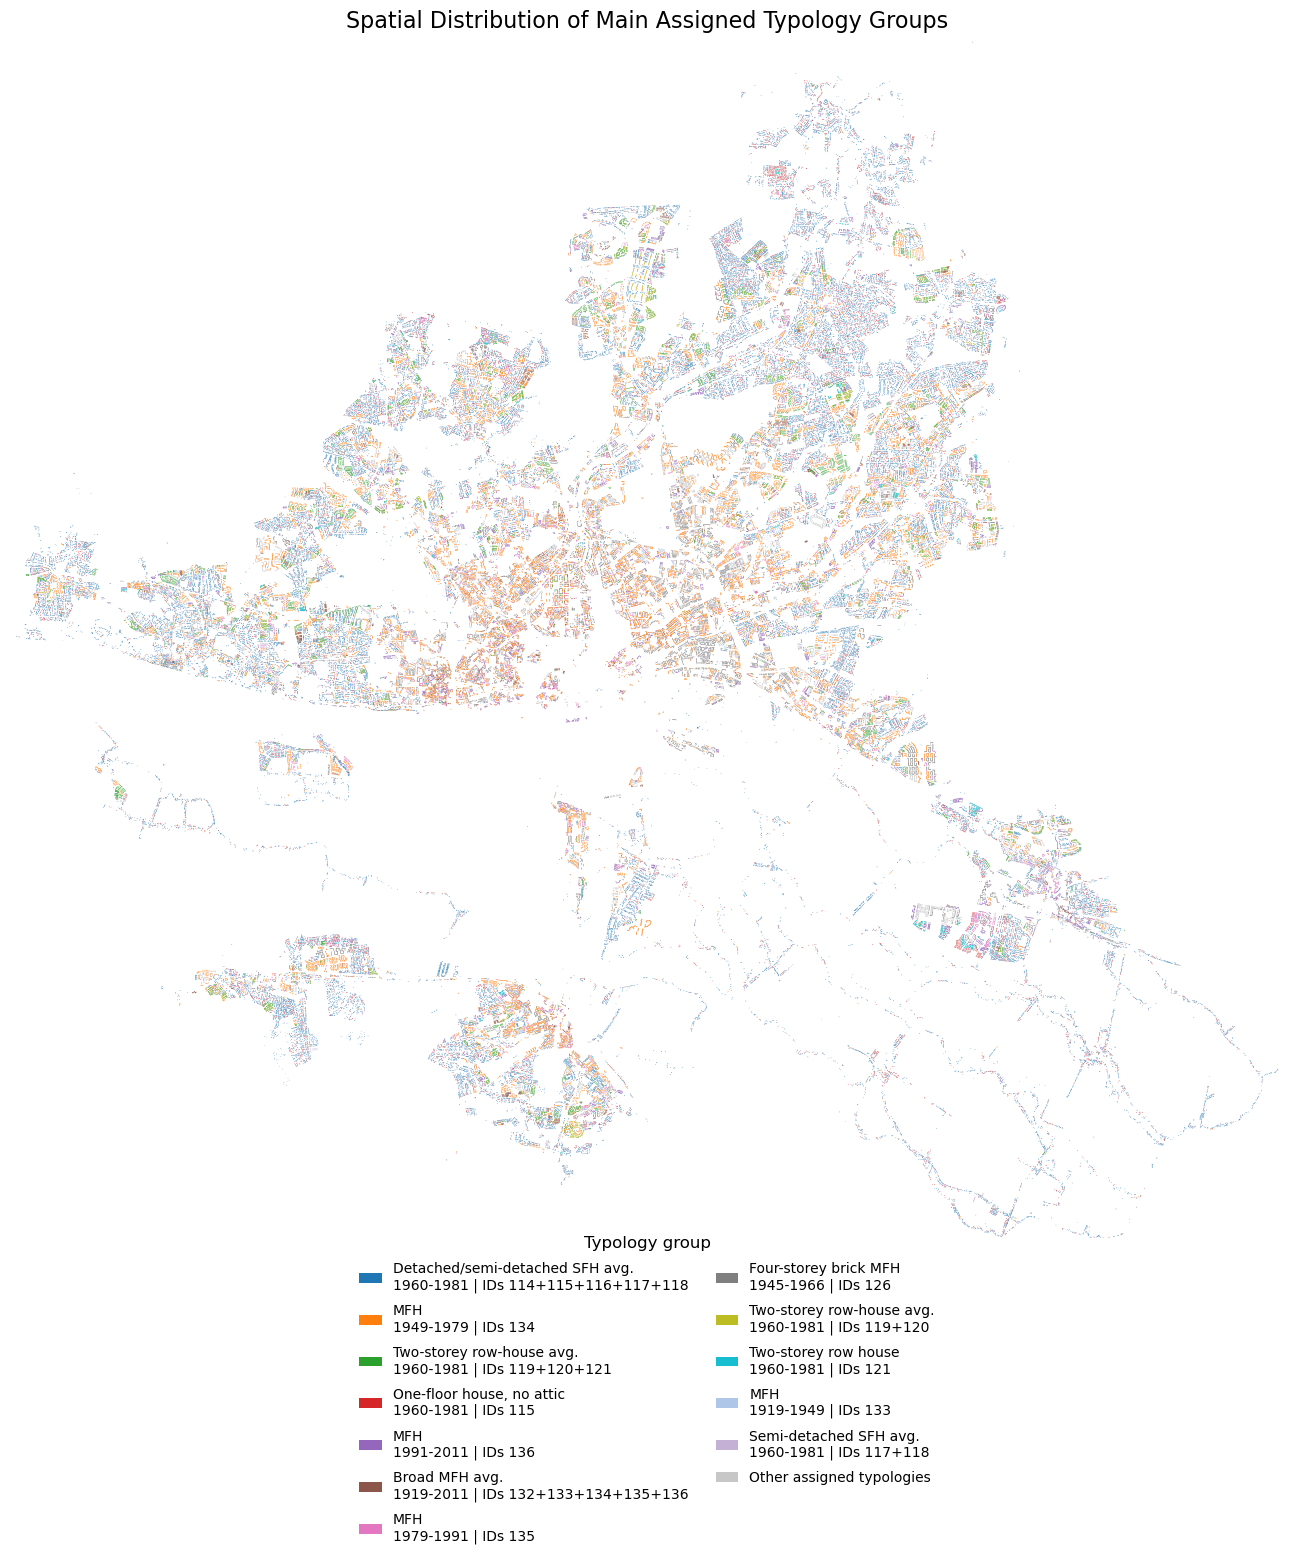

Typology groups mapped: 13
Buildings mapped: 157065
Output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_typology_spatial_distribution_map.png


In [11]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

if "PROCESSED_DIR" not in globals() or "MAP_DIR" not in globals():
    PROJECT_ROOT = find_project_root() if "find_project_root" in globals() else Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PROCESSED_DIR = PROJECT_ROOT / "data/processed"
    MAP_DIR = PROJECT_ROOT / "results/maps"
    MAP_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RESIDENTIAL_PATH = globals().get(
    "OUTPUT_RESIDENTIAL_PATH",
    PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg",
)
HEEREN_PATH = globals().get(
    "HEEREN_PATH",
    PROJECT_ROOT / "data/raw/Heeren_Germany Only.csv",
)
TYPOLOGY_SPATIAL_DISTRIBUTION_MAP_PATH = globals().get(
    "TYPOLOGY_SPATIAL_DISTRIBUTION_MAP_PATH",
    MAP_DIR / "hamburg_typology_spatial_distribution_map.png",
)

if "gdf_materials" not in globals():
    if OUTPUT_RESIDENTIAL_PATH.exists():
        gdf_materials = gpd.read_file(OUTPUT_RESIDENTIAL_PATH)
    else:
        raise NameError(
            "gdf_materials is not defined and no exported residential result exists. "
            "Run the assignment/material-stock cell first."
        )

required_typology_map_columns = {"is_main_residential_stock", "assigned_typology_ids", "assignment_level", "total_material_stock_t", "geometry"}
missing_typology_map_columns = required_typology_map_columns.difference(gdf_materials.columns)
if missing_typology_map_columns:
    raise KeyError(
        "Typology spatial distribution map requires the completed assignment output. "
        f"Missing columns: {sorted(missing_typology_map_columns)}. Run the assignment/material-stock cell first."
    )

if "summarize_by_group" not in globals():
    def summarize_by_group(gdf, group_column):
        work = gdf.copy()
        assigned_level_prefixes = globals().get("ASSIGNED_LEVEL_PREFIXES", ("1_", "2_", "3_", "4_", "5_"))
        assigned = work["assignment_level"].fillna("").astype("string").str.startswith(assigned_level_prefixes, na=False)
        work["residential_building_count_helper"] = work["is_main_residential_stock"].fillna(False).astype(bool).astype(int)
        work["assigned_material_stock_t"] = pd.to_numeric(work["total_material_stock_t"], errors="coerce").where(assigned, 0)

        summary = (
            work
            .groupby(group_column, dropna=False)
            .agg(
                building_count=(group_column, "size"),
                residential_buildings=("residential_building_count_helper", "sum"),
                total_material_stock_t=("assigned_material_stock_t", "sum"),
            )
            .reset_index()
            .sort_values("building_count", ascending=False)
        )
        total_residential_buildings = int(work["is_main_residential_stock"].fillna(False).astype(bool).sum())
        total_assigned_stock = work.loc[assigned, "assigned_material_stock_t"].sum(skipna=True)
        summary["share_of_residential_buildings_pct"] = 0.0
        if total_residential_buildings > 0:
            summary["share_of_residential_buildings_pct"] = (summary["residential_buildings"] / total_residential_buildings * 100).round(2)
        summary["share_of_assigned_material_stock_pct"] = 0.0
        if total_assigned_stock > 0:
            summary["share_of_assigned_material_stock_pct"] = (summary["total_material_stock_t"] / total_assigned_stock * 100).round(2)
        return summary

if "summary_by_typology_ids" not in globals():
    summary_by_typology_ids = summarize_by_group(
        gdf_materials[gdf_materials["is_main_residential_stock"].fillna(False).astype(bool)].copy(),
        "assigned_typology_ids",
    )

if "typology_short_summary" not in globals():
    if "heeren_typology_name_by_id" not in globals() and "heeren" in globals():
        heeren_typology_name_by_id = heeren.set_index("heeren_id")["building_description_clean"].to_dict()
    elif "heeren_typology_name_by_id" not in globals():
        heeren_typology_name_by_id = {}

    def typology_name_for_ids(value):
        if pd.isna(value):
            return "No assigned typology"
        ids = [part.strip() for part in str(value).split("+") if part.strip()]
        names = [heeren_typology_name_by_id.get(id_value, f"Typology {id_value}") for id_value in ids]
        if len(names) == 1:
            return names[0]
        return "Average: " + "; ".join(names)

    typology_short_summary = (
        summary_by_typology_ids[summary_by_typology_ids["assigned_typology_ids"].notna()]
        .assign(
            **{
                "Typology name": lambda df: df["assigned_typology_ids"].map(typology_name_for_ids),
                "id": lambda df: df["assigned_typology_ids"],
                "Nr of buildings": lambda df: df["building_count"].astype(int),
                "% of buildings": lambda df: df["share_of_residential_buildings_pct"],
                "total material stock": lambda df: df["total_material_stock_t"].round(0),
                "% of materials": lambda df: df["share_of_assigned_material_stock_pct"],
            }
        )
        [["Typology name", "id", "Nr of buildings", "% of buildings", "total material stock", "% of materials"]]
        .sort_values("Nr of buildings", ascending=False)
        .reset_index(drop=True)
    )

if "heeren" not in globals() and HEEREN_PATH.exists():
    heeren = pd.read_csv(
        HEEREN_PATH,
        sep=";",
        skipinitialspace=True,
        encoding="utf-8-sig",
        na_values=["NA", "NULL", "", " "],
    )
    heeren.columns = heeren.columns.str.strip()
    for column in heeren.select_dtypes(include="object").columns:
        heeren[column] = heeren[column].astype("string").str.strip()
    heeren["heeren_id"] = pd.to_numeric(heeren["id"], errors="coerce").astype("Int64").astype("string")
    heeren["building_description_clean"] = heeren["building_description"].astype("string").str.strip()
    heeren["construction_period_start_clean"] = pd.to_numeric(heeren["construction_period_start"], errors="coerce")
    heeren["construction_period_end_clean"] = pd.to_numeric(heeren["construction_period_end"], errors="coerce")

TYPOLOGY_SHORT_DESCRIPTIONS = {
    "114+115+116+117+118": "Detached/semi-detached SFH avg.",
    "119+120+121": "Two-storey row-house avg.",
    "119+120": "Two-storey row-house avg.",
    "117+118": "Semi-detached SFH avg.",
    "126+127": "Four-storey MFH avg.",
    "126+127+128": "MFH construction-system avg.",
    "132+133+134+135+136": "Broad MFH avg.",
    "122+123+124+125+126+127+128+131": "Low-rise MFH avg.",
    "122+123+124+125+126+127": "Four-storey MFH avg.",
}

def construction_period_label_for_ids(value):
    if "heeren" not in globals() or pd.isna(value):
        return "period n/a"
    ids = [part.strip() for part in str(value).split("+") if part.strip()]
    rows = heeren[heeren["heeren_id"].astype("string").isin(ids)].copy()
    if rows.empty:
        return "period n/a"
    starts = pd.to_numeric(rows["construction_period_start_clean"], errors="coerce").dropna()
    ends = pd.to_numeric(rows["construction_period_end_clean"], errors="coerce").dropna()
    start = int(starts.min()) if not starts.empty else None
    end = int(ends.max()) if not ends.empty else None
    if start is None and end is None:
        return "period n/a"
    if start is None:
        return f"<= {end}"
    if end is None:
        return f">= {start}"
    return f"{start}-{end}"

def short_typology_description_for_ids(value):
    id_text = str(value)
    if id_text in TYPOLOGY_SHORT_DESCRIPTIONS:
        return TYPOLOGY_SHORT_DESCRIPTIONS[id_text]
    if "heeren" not in globals():
        return "Typology group"
    ids = [part.strip() for part in id_text.split("+") if part.strip()]
    rows = heeren[heeren["heeren_id"].astype("string").isin(ids)].copy()
    if rows.empty:
        return "Typology group"
    description = str(rows.iloc[0].get("building_description_clean", "Typology group"))
    replacements = {
        "One floor house - w/ attic": "One-floor house, attic",
        "One floor house - no attic": "One-floor house, no attic",
        "One floor duplex house - w/ attic": "One-floor duplex, attic",
        "Two floor house - townhouse - no attic": "Two-storey row house",
        "Four floor - multifamily - brick": "Four-storey brick MFH",
        "Four floor - multifamily - block and strip": "Four-storey block/strip MFH",
        "Five floor - multifamily - panel": "Five-storey panel MFH",
        "Three floor - multifamily - brick": "Three-storey brick MFH",
        "Eleven floor - multifamily - panel": "Eleven-storey panel MFH",
        "Eighteen floor - multifamily - panel": "Eighteen-storey panel MFH",
    }
    for old, new in replacements.items():
        if description.startswith(old):
            return new
    return description[:38]

def typology_legend_label_for_ids(value):
    id_text = str(value)
    description = short_typology_description_for_ids(id_text)
    period = construction_period_label_for_ids(id_text)
    return f"{description} | {period} | IDs {id_text}"

valid_typology_summary = typology_short_summary.loc[
    typology_short_summary["id"].notna()
    & typology_short_summary["id"].astype("string").str.strip().ne("")
]
top_typology_ids = valid_typology_summary.head(12)["id"].astype(str).tolist()
label_by_typology_id = {id_value: typology_legend_label_for_ids(id_value) for id_value in top_typology_ids}

assigned_level_prefixes = globals().get("ASSIGNED_LEVEL_PREFIXES", ("1_", "2_", "3_", "4_", "5_"))
typology_ids_for_map = gdf_materials["assigned_typology_ids"].fillna("").astype("string").str.strip()
assigned_typology_map_mask = (
    gdf_materials["assignment_level"].fillna("").astype("string").str.startswith(assigned_level_prefixes, na=False)
    & typology_ids_for_map.ne("")
    & gdf_materials.geometry.notna()
    & ~gdf_materials.geometry.is_empty
)
typology_map_gdf = gdf_materials[
    assigned_typology_map_mask
].copy()
typology_map_gdf["typology_map_group"] = typology_map_gdf["assigned_typology_ids"].astype(str)
typology_map_gdf.loc[
    ~typology_map_gdf["typology_map_group"].isin(top_typology_ids),
    "typology_map_group",
] = "Other assigned typologies"
typology_map_gdf["typology_map_label"] = typology_map_gdf["typology_map_group"].map(label_by_typology_id).fillna("Other assigned typologies")

plot_order = [label_by_typology_id[id_value] for id_value in top_typology_ids if id_value in label_by_typology_id]
if "Other assigned typologies" in typology_map_gdf["typology_map_label"].unique():
    plot_order.append("Other assigned typologies")
color_values = [plt.cm.tab20.colors[i] for i in [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 1, 9, 15]][:len(plot_order)]
color_by_label = dict(zip(plot_order, color_values))

# Large canvas keeps the map itself above 5000 pixels tall, with legend below.
TYPOLOGY_MAP_DPI = 500
fig, ax = plt.subplots(figsize=(16, 16))
fig.subplots_adjust(left=0.015, right=0.985, bottom=0.21, top=0.965)
for label in plot_order:
    subset = typology_map_gdf[typology_map_gdf["typology_map_label"].eq(label)]
    if subset.empty:
        continue
    subset.plot(
        ax=ax,
        color=color_by_label[label],
        linewidth=0.10,
        edgecolor=color_by_label[label],
        label=label,
    )

ax.margins(0.005)
ax.set_title("Spatial Distribution of Main Assigned Typology Groups", fontsize=16)
ax.set_axis_off()
legend_handles = [
    Patch(facecolor=color_by_label[label], edgecolor="none", label=label.replace(" | ", "\n", 1))
    for label in plot_order
]
fig.legend(
    handles=legend_handles,
    title="Typology group",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    handlelength=1.6,
    columnspacing=2.0,
    labelspacing=0.8,
)
# Preserve the square canvas; tight cropping would change the pixel dimensions.
with plt.rc_context({"savefig.bbox": None}):
    fig.savefig(TYPOLOGY_SPATIAL_DISTRIBUTION_MAP_PATH, dpi=TYPOLOGY_MAP_DPI, facecolor="white")
    fig.savefig(MAP_DIR / "hamburg_typology_spatial_distribution_map_8000px.png", dpi=TYPOLOGY_MAP_DPI, facecolor="white")
plt.show(block=False)
plt.close(fig)

print("Typology groups mapped:", len(plot_order))
print("Buildings mapped:", len(typology_map_gdf))
print("Output:", TYPOLOGY_SPATIAL_DISTRIBUTION_MAP_PATH)


,source,material_column,material,material_stock_t,total_stock_t,material_fraction_pct
0,Cascade assignment - full cascade scope,concrete_stock_t,Concrete,7.517653e+07,1.713075e+08,43.88
1,Cascade assignment - full cascade scope,brick_stock_t,Brick,4.591043e+07,1.713075e+08,26.80
2,Cascade assignment - full cascade scope,plaster_board_gypsum_stock_t,Plaster Board Gypsum,1.849763e+07,1.713075e+08,10.80
3,Cascade assignment - full cascade scope,mortar_plaster_stock_t,Mortar Plaster,1.221356e+07,1.713075e+08,7.13
4,Cascade assignment - full cascade scope,unspecified_metal_stock_t,Unspecified Metal,7.450762e+06,1.713075e+08,4.35
5,Cascade assignment - full cascade scope,mineral_fill_stock_t,Mineral Fill,5.621380e+06,1.713075e+08,3.28
6,Cascade assignment - full cascade scope,other_unspecified_material_stock_t,Other Unspecified Material,3.066428e+06,1.713075e+08,1.79
7,Cascade assignment - full cascade scope,wood_stock_t,Wood,1.942986e+06,1.713075e+08,1.13
8,Cascade assignment - full cascade scope,insulation_unspecified_stock_t,Insulation Unspecified,1.336642e+06,1.713075e+08,0.78
9,Cascade assignment - full cascade scope,bitumen_stock_t,Bitumen,9.116726e+04,1.713075e+08,0.05


,source,material_column,material,material_stock_t,total_stock_t,material_fraction_pct
0,IÖR benchmark - full benchmark scope,ioer_material_group_1_stock_t,Standardbeton,6.073727e+07,1.495376e+08,40.62
1,IÖR benchmark - full benchmark scope,ioer_material_group_3_stock_t,Ziegelsteine,2.329907e+07,1.495376e+08,15.58
2,IÖR benchmark - full benchmark scope,ioer_material_group_16_stock_t,Kalksandsteine,1.661128e+07,1.495376e+08,11.11
3,IÖR benchmark - full benchmark scope,ioer_material_group_8_stock_t,"Kalkhaltige Putze, Mörtel",1.253203e+07,1.495376e+08,8.38
4,IÖR benchmark - full benchmark scope,ioer_material_group_27_stock_t,Mineralische Schüttungen,8.876927e+06,1.495376e+08,5.94
5,IÖR benchmark - full benchmark scope,ioer_material_group_42_stock_t,Eisenmetalle,6.674460e+06,1.495376e+08,4.46
6,IÖR benchmark - full benchmark scope,ioer_material_group_12_stock_t,Kalkhaltige Estriche,5.471881e+06,1.495376e+08,3.66
7,IÖR benchmark - full benchmark scope,ioer_material_group_9_stock_t,"Gips-/anhydrithaltige Putze, Mörtel",4.167600e+06,1.495376e+08,2.79
8,IÖR benchmark - full benchmark scope,ioer_material_group_29_stock_t,Natursteine,2.527231e+06,1.495376e+08,1.69
9,IÖR benchmark - full benchmark scope,ioer_material_group_31_stock_t,Schnittholz,1.789087e+06,1.495376e+08,1.20


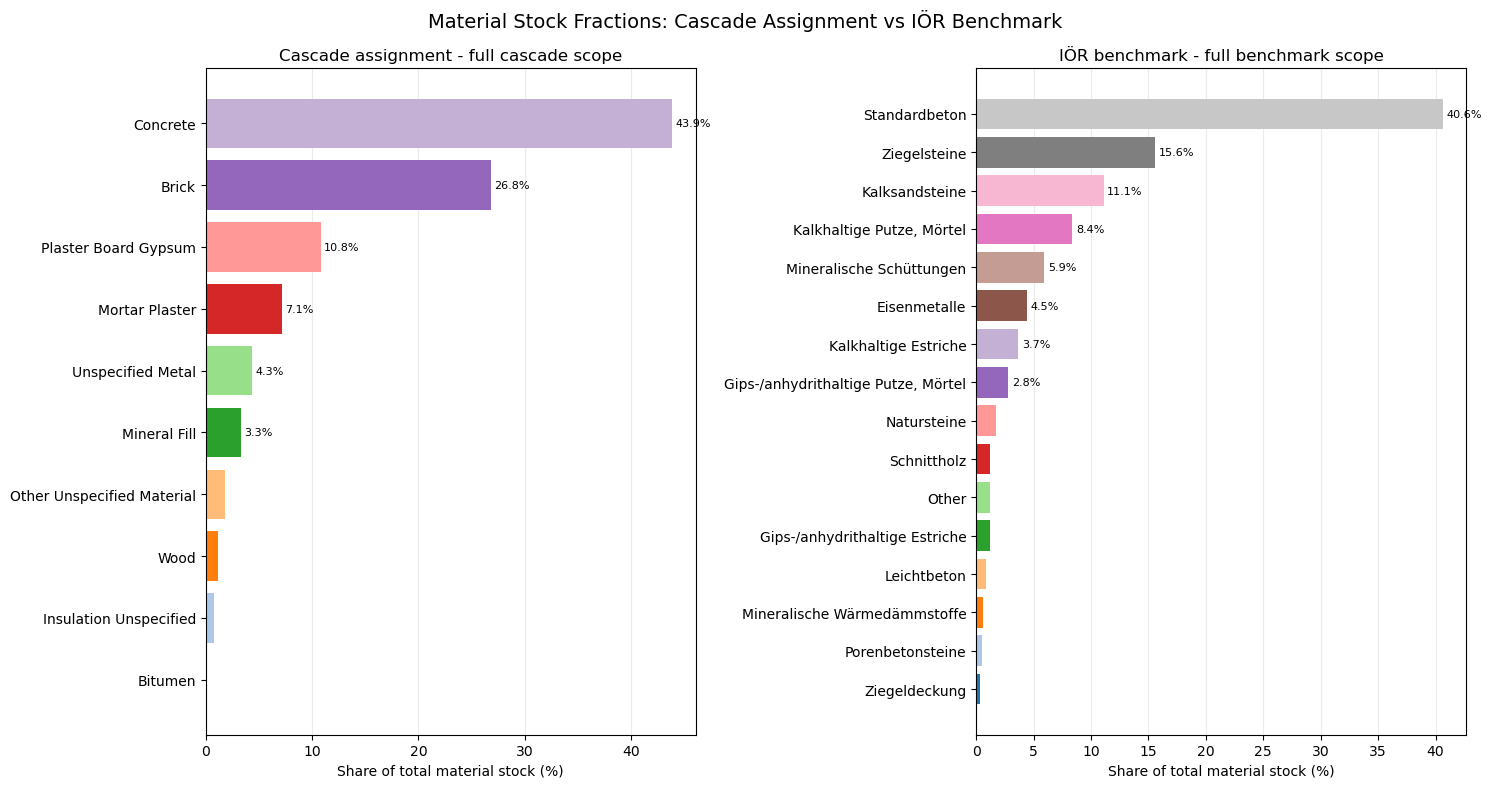

,source,material_column,material,material_stock_t,total_stock_t,material_fraction_pct
0,Cascade assignment - common scope,concrete_stock_t,Concrete,7.517653e+07,1.713075e+08,43.88
1,Cascade assignment - common scope,brick_stock_t,Brick,4.591043e+07,1.713075e+08,26.80
2,Cascade assignment - common scope,plaster_board_gypsum_stock_t,Plaster Board Gypsum,1.849763e+07,1.713075e+08,10.80
3,Cascade assignment - common scope,mortar_plaster_stock_t,Mortar Plaster,1.221356e+07,1.713075e+08,7.13
4,Cascade assignment - common scope,unspecified_metal_stock_t,Unspecified Metal,7.450762e+06,1.713075e+08,4.35
5,Cascade assignment - common scope,mineral_fill_stock_t,Mineral Fill,5.621380e+06,1.713075e+08,3.28
6,Cascade assignment - common scope,other_unspecified_material_stock_t,Other Unspecified Material,3.066428e+06,1.713075e+08,1.79
7,Cascade assignment - common scope,wood_stock_t,Wood,1.942986e+06,1.713075e+08,1.13
8,Cascade assignment - common scope,insulation_unspecified_stock_t,Insulation Unspecified,1.336642e+06,1.713075e+08,0.78
9,Cascade assignment - common scope,bitumen_stock_t,Bitumen,9.116726e+04,1.713075e+08,0.05


,source,material_column,material,material_stock_t,total_stock_t,material_fraction_pct
0,IÖR benchmark - common scope,ioer_material_group_1_stock_t,Standardbeton,5.062919e+07,1.238909e+08,40.87
1,IÖR benchmark - common scope,ioer_material_group_3_stock_t,Ziegelsteine,2.019272e+07,1.238909e+08,16.30
2,IÖR benchmark - common scope,ioer_material_group_16_stock_t,Kalksandsteine,1.261865e+07,1.238909e+08,10.19
3,IÖR benchmark - common scope,ioer_material_group_8_stock_t,"Kalkhaltige Putze, Mörtel",1.053508e+07,1.238909e+08,8.50
4,IÖR benchmark - common scope,ioer_material_group_27_stock_t,Mineralische Schüttungen,7.284084e+06,1.238909e+08,5.88
5,IÖR benchmark - common scope,ioer_material_group_42_stock_t,Eisenmetalle,5.594106e+06,1.238909e+08,4.52
6,IÖR benchmark - common scope,ioer_material_group_12_stock_t,Kalkhaltige Estriche,4.480885e+06,1.238909e+08,3.62
7,IÖR benchmark - common scope,ioer_material_group_9_stock_t,"Gips-/anhydrithaltige Putze, Mörtel",3.493498e+06,1.238909e+08,2.82
8,IÖR benchmark - common scope,ioer_material_group_29_stock_t,Natursteine,2.071910e+06,1.238909e+08,1.67
9,IÖR benchmark - common scope,ioer_material_group_13_stock_t,Gips-/anhydrithaltige Estriche,1.491103e+06,1.238909e+08,1.20


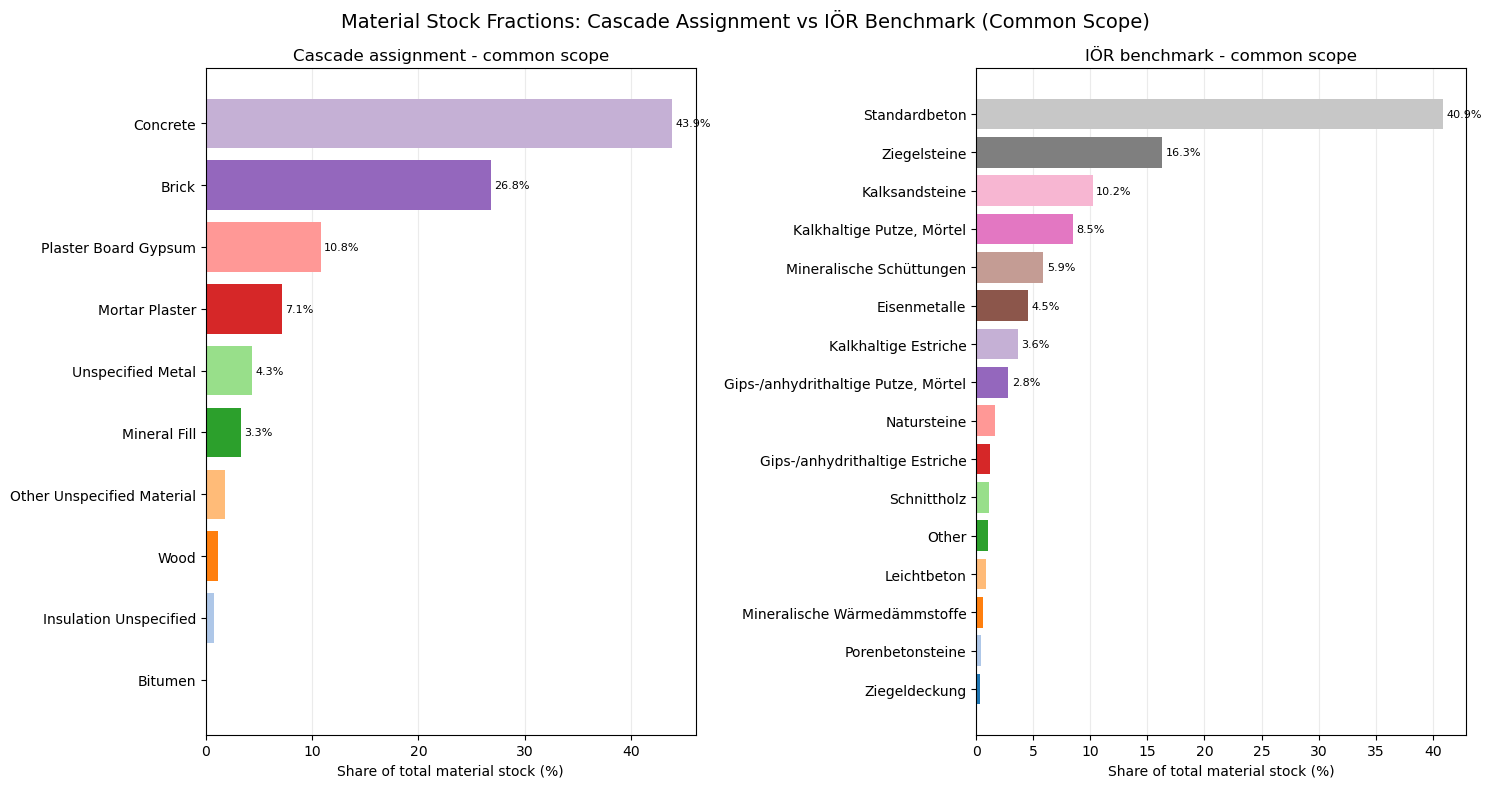

Material fraction summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_material_fraction_comparison_summary.csv
Material fraction chart output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_material_fraction_comparison.png
Common-scope material fraction summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_material_fraction_common_scope_comparison_summary.csv
Common-scope material fraction chart output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_material_fraction_common_scope_comparison.png


In [12]:
if "PROCESSED_DIR" not in globals() or "MAP_DIR" not in globals():
    PROJECT_ROOT = find_project_root() if "find_project_root" in globals() else Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PROCESSED_DIR = PROJECT_ROOT / "data/processed"
    MAP_DIR = PROJECT_ROOT / "results/maps"
    MAP_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RESIDENTIAL_PATH = globals().get(
    "OUTPUT_RESIDENTIAL_PATH",
    PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg",
)
OUTPUT_MATERIAL_FRACTION_SUMMARY_PATH = globals().get(
    "OUTPUT_MATERIAL_FRACTION_SUMMARY_PATH",
    PROCESSED_DIR / "hamburg_material_fraction_comparison_summary.csv",
)
OUTPUT_MATERIAL_FRACTION_COMMON_SCOPE_SUMMARY_PATH = globals().get(
    "OUTPUT_MATERIAL_FRACTION_COMMON_SCOPE_SUMMARY_PATH",
    PROCESSED_DIR / "hamburg_material_fraction_common_scope_comparison_summary.csv",
)
OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH = globals().get(
    "OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH",
    PROCESSED_DIR / "hamburg_ioer_benchmark_material_group_summary.csv",
)
MATERIAL_FRACTION_COMPARISON_CHART_PATH = globals().get(
    "MATERIAL_FRACTION_COMPARISON_CHART_PATH",
    MAP_DIR / "hamburg_material_fraction_comparison.png",
)
MATERIAL_FRACTION_COMMON_SCOPE_CHART_PATH = globals().get(
    "MATERIAL_FRACTION_COMMON_SCOPE_CHART_PATH",
    MAP_DIR / "hamburg_material_fraction_common_scope_comparison.png",
)

if "PROCESSED_DIR" not in globals():
    PROJECT_ROOT = find_project_root() if "find_project_root" in globals() else Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PROCESSED_DIR = PROJECT_ROOT / "data/processed"

OUTPUT_BUILDINGS_PATH = globals().get(
    "OUTPUT_BUILDINGS_PATH",
    PROCESSED_DIR / "hamburg_buildings_with_heeren_material_estimates.gpkg",
)
OUTPUT_RESIDENTIAL_PATH = globals().get(
    "OUTPUT_RESIDENTIAL_PATH",
    PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg",
)

if "gdf_materials" not in globals():
    if OUTPUT_RESIDENTIAL_PATH.exists():
        gdf_materials = gpd.read_file(OUTPUT_RESIDENTIAL_PATH)
        residential_mask = pd.Series(True, index=gdf_materials.index)
        assigned_level_prefixes = globals().get("ASSIGNED_LEVEL_PREFIXES", ("1_", "2_", "3_", "4_", "5_"))
        assigned_mask = gdf_materials["assignment_level"].fillna("").astype("string").str.startswith(assigned_level_prefixes, na=False)
    else:
        raise NameError(
            "gdf_materials is not defined and no exported residential result exists. "
            "Run the assignment/material-stock cell first."
        )

if "residential_mask" not in globals():
    residential_mask = gdf_materials["is_main_residential_stock"].fillna(False).astype(bool)
if "assigned_mask" not in globals():
    assigned_level_prefixes = globals().get("ASSIGNED_LEVEL_PREFIXES", ("1_", "2_", "3_", "4_", "5_"))
    assigned_mask = gdf_materials["assignment_level"].fillna("").astype("string").str.startswith(assigned_level_prefixes, na=False)

def material_fraction_summary(gdf, stock_columns, label_by_column, source_label, scope_mask):
    rows = []
    for column in stock_columns:
        tonnes = pd.to_numeric(gdf.loc[scope_mask, column], errors="coerce").sum(skipna=True)
        rows.append({
            "source": source_label,
            "material_column": column,
            "material": label_by_column.get(column, column),
            "material_stock_t": tonnes,
        })

    summary = pd.DataFrame(rows)
    summary = summary[summary["material_stock_t"].gt(0)].copy()
    total_stock_t = summary["material_stock_t"].sum(skipna=True)
    summary["total_stock_t"] = total_stock_t
    summary["material_fraction_pct"] = 0.0
    if total_stock_t > 0:
        summary["material_fraction_pct"] = (summary["material_stock_t"] / total_stock_t * 100).round(2)
    return summary.sort_values("material_stock_t", ascending=False).reset_index(drop=True)


def collapse_material_summary_for_plot(summary, top_n=15):
    plot_summary = summary.sort_values("material_stock_t", ascending=False).copy()
    if len(plot_summary) <= top_n:
        return plot_summary

    top = plot_summary.head(top_n).copy()
    other = plot_summary.iloc[top_n:]
    total_stock_t = plot_summary["material_stock_t"].sum(skipna=True)
    other_stock_t = other["material_stock_t"].sum(skipna=True)
    other_row = pd.DataFrame([{
        "source": plot_summary["source"].iloc[0],
        "material_column": "other",
        "material": "Other",
        "material_stock_t": other_stock_t,
        "total_stock_t": total_stock_t,
        "material_fraction_pct": round(other_stock_t / total_stock_t * 100, 2) if total_stock_t > 0 else 0.0,
    }])
    return pd.concat([top, other_row], ignore_index=True)


def plot_material_fraction_comparison(primary_summary, ioer_summary, output_path, title, top_n=15):
    plot_inputs = [
        collapse_material_summary_for_plot(primary_summary, top_n=top_n),
        collapse_material_summary_for_plot(ioer_summary, top_n=top_n),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=False)
    for ax, plot_data in zip(axes, plot_inputs):
        plot_data = plot_data.sort_values("material_fraction_pct", ascending=True)
        colors = plt.cm.tab20(range(len(plot_data)))
        ax.barh(plot_data["material"], plot_data["material_fraction_pct"], color=colors)
        ax.set_title(plot_data["source"].iloc[0])
        ax.set_xlabel("Share of total material stock (%)")
        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)
        for y, value in enumerate(plot_data["material_fraction_pct"]):
            if value >= 2:
                ax.text(value + 0.3, y, f"{value:.1f}%", va="center", fontsize=8)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show(block=False)
    plt.close(fig)


if "material_columns" not in globals():
    material_columns = [
        column.removesuffix("_stock_t")
        for column in gdf_materials.columns
        if column.endswith("_stock_t")
        and column != "total_material_stock_t"
        and not column.startswith("ioer_material_group_")
        and not column.startswith("ortlepp_variant_")
    ]

primary_stock_columns = [f"{material}_stock_t" for material in material_columns if f"{material}_stock_t" in gdf_materials.columns]
primary_material_labels = {
    f"{material}_stock_t": material.replace("_", " ").replace("PVC", "PVC").title()
    for material in material_columns
}
primary_material_labels["PVC_stock_t"] = "PVC"

ioer_stock_columns = [
    column for column in gdf_materials.columns
    if column.startswith("ioer_material_group_") and column.endswith("_stock_t")
]
if "ioer_reference_material_long" in globals():
    ioer_material_labels = (
        ioer_reference_material_long
        .drop_duplicates("ioer_material_group_field")
        .set_index("ioer_material_group_field")["Baumaterialgruppe"]
        .to_dict()
    )
else:
    ioer_material_labels = (
        pd.read_csv(OUTPUT_IOER_MATERIAL_GROUP_SUMMARY_PATH)
        .drop_duplicates("ioer_material_group_id")
        .assign(ioer_material_group_field=lambda df: "ioer_material_group_" + df["ioer_material_group_id"].astype(int).astype(str) + "_stock_t")
        .set_index("ioer_material_group_field")["ioer_material_group_name"]
        .to_dict()
    )

primary_material_fraction_summary = material_fraction_summary(
    gdf_materials,
    primary_stock_columns,
    primary_material_labels,
    "Cascade assignment - full cascade scope",
    residential_mask & assigned_mask,
)
ioer_material_fraction_summary = material_fraction_summary(
    gdf_materials,
    ioer_stock_columns,
    ioer_material_labels,
    "IÖR benchmark - full benchmark scope",
    residential_mask & gdf_materials["ioer_total_material_stock_t"].notna(),
)
common_cascade_ioer_mask = residential_mask & assigned_mask & gdf_materials["ioer_total_material_stock_t"].notna()
primary_material_fraction_common_scope_summary = material_fraction_summary(
    gdf_materials,
    primary_stock_columns,
    primary_material_labels,
    "Cascade assignment - common scope",
    common_cascade_ioer_mask,
)
ioer_material_fraction_common_scope_summary = material_fraction_summary(
    gdf_materials,
    ioer_stock_columns,
    ioer_material_labels,
    "IÖR benchmark - common scope",
    common_cascade_ioer_mask,
)

material_fraction_comparison_summary = pd.concat([
    primary_material_fraction_summary,
    ioer_material_fraction_summary,
], ignore_index=True)
material_fraction_comparison_summary.to_csv(OUTPUT_MATERIAL_FRACTION_SUMMARY_PATH, index=False)
material_fraction_common_scope_comparison_summary = pd.concat([
    primary_material_fraction_common_scope_summary,
    ioer_material_fraction_common_scope_summary,
], ignore_index=True)
material_fraction_common_scope_comparison_summary.to_csv(OUTPUT_MATERIAL_FRACTION_COMMON_SCOPE_SUMMARY_PATH, index=False)

display(primary_material_fraction_summary.head(20))
display(ioer_material_fraction_summary.head(20))
plot_material_fraction_comparison(
    primary_material_fraction_summary,
    ioer_material_fraction_summary,
    MATERIAL_FRACTION_COMPARISON_CHART_PATH,
    "Material Stock Fractions: Cascade Assignment vs IÖR Benchmark",
    top_n=15,
)
display(primary_material_fraction_common_scope_summary.head(20))
display(ioer_material_fraction_common_scope_summary.head(20))
plot_material_fraction_comparison(
    primary_material_fraction_common_scope_summary,
    ioer_material_fraction_common_scope_summary,
    MATERIAL_FRACTION_COMMON_SCOPE_CHART_PATH,
    "Material Stock Fractions: Cascade Assignment vs IÖR Benchmark (Common Scope)",
    top_n=15,
)
print("Material fraction summary output:", OUTPUT_MATERIAL_FRACTION_SUMMARY_PATH)
print("Material fraction chart output:", MATERIAL_FRACTION_COMPARISON_CHART_PATH)
print("Common-scope material fraction summary output:", OUTPUT_MATERIAL_FRACTION_COMMON_SCOPE_SUMMARY_PATH)
print("Common-scope material fraction chart output:", MATERIAL_FRACTION_COMMON_SCOPE_CHART_PATH)


In [13]:
if "PROCESSED_DIR" not in globals() or "MAP_DIR" not in globals():
    PROJECT_ROOT = find_project_root() if "find_project_root" in globals() else Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PROCESSED_DIR = PROJECT_ROOT / "data/processed"
    MAP_DIR = PROJECT_ROOT / "results/maps"
    MAP_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RESIDENTIAL_PATH = globals().get(
    "OUTPUT_RESIDENTIAL_PATH",
    PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg",
)

if "gdf_materials" not in globals():
    if OUTPUT_BUILDINGS_PATH.exists():
        gdf_materials = gpd.read_file(OUTPUT_BUILDINGS_PATH)
    else:
        raise NameError(
            "gdf_materials is not defined and no exported all-building result exists. "
            "Run the assignment/material-stock cell first."
        )

required_export_columns = {"is_main_residential_stock", "total_material_stock_t", "geometry"}
missing_export_columns = required_export_columns.difference(gdf_materials.columns)
if missing_export_columns:
    raise KeyError(
        "Cell 13 export requires the completed material assignment output. "
        f"Missing columns: {sorted(missing_export_columns)}. Run the assignment/material-stock cell first."
    )

export_gdf = gdf_materials.copy()
for col in export_gdf.select_dtypes(include=["object", "string"]).columns:
    export_gdf[col] = export_gdf[col].fillna("")

export_gdf.to_file(OUTPUT_BUILDINGS_PATH, driver="GPKG", mode="w")
export_gdf[export_gdf["is_main_residential_stock"]].to_file(OUTPUT_RESIDENTIAL_PATH, driver="GPKG", mode="w")

print("All-building output:", OUTPUT_BUILDINGS_PATH)
print("Residential output:", OUTPUT_RESIDENTIAL_PATH)
print("Assignment summary output:", OUTPUT_SUMMARY_PATH)
print("Confidence summary output:", OUTPUT_CONFIDENCE_SUMMARY_PATH)
print("Quality flags summary output:", OUTPUT_QUALITY_FLAGS_SUMMARY_PATH)

All-building output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_buildings_with_heeren_material_estimates.gpkg
Residential output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_residential_buildings_with_heeren_material_estimates.gpkg
Assignment summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_assignment_level_summary.csv
Confidence summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_confidence_tier_summary.csv
Quality flags summary output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_quality_flags_summary.csv


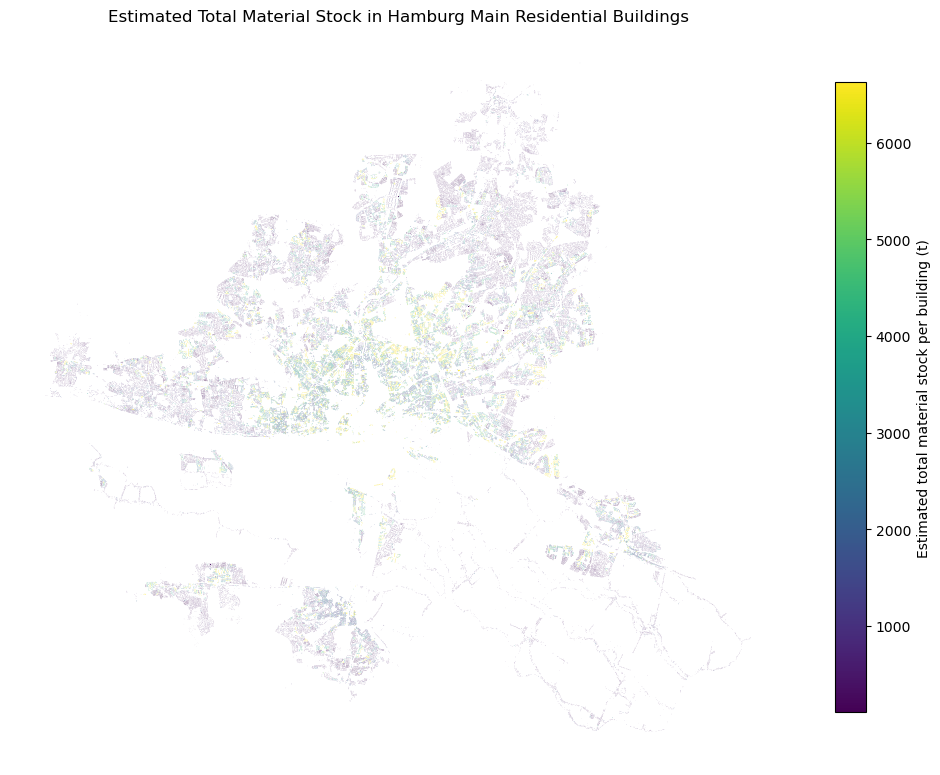

Buildings mapped: 157025
Output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_residential_total_material_stock_map.png


In [14]:
if "gdf_materials" not in globals():
    if OUTPUT_RESIDENTIAL_PATH.exists():
        gdf_materials = gpd.read_file(OUTPUT_RESIDENTIAL_PATH)
    else:
        raise NameError(
            "gdf_materials is not defined and no exported residential result exists. "
            "Run the assignment/material-stock cell first."
        )

required_map_columns = {"is_main_residential_stock", "total_material_stock_t", "geometry"}
missing_map_columns = required_map_columns.difference(gdf_materials.columns)
if missing_map_columns:
    raise KeyError(
        "Total material stock map requires the completed material assignment output. "
        f"Missing columns: {sorted(missing_map_columns)}. Run the assignment/material-stock cell first."
    )

plot_gdf = gdf_materials.copy()
plot_gdf["total_material_stock_t"] = pd.to_numeric(plot_gdf["total_material_stock_t"], errors="coerce")

valid_plot_mask = (
    plot_gdf["is_main_residential_stock"].fillna(False).astype(bool)
    & plot_gdf["total_material_stock_t"].notna()
    & plot_gdf["total_material_stock_t"].gt(0)
    & plot_gdf.geometry.notna()
    & ~plot_gdf.geometry.is_empty
)
plot_gdf = plot_gdf.loc[valid_plot_mask].copy()

if plot_gdf.empty:
    raise ValueError("No main residential buildings with positive total material stock and valid geometry to map.")

vmin = plot_gdf["total_material_stock_t"].quantile(0.02)
vmax = plot_gdf["total_material_stock_t"].quantile(0.98)
if pd.isna(vmin) or pd.isna(vmax):
    raise ValueError("Cannot calculate map color scale from total_material_stock_t.")
if vmin == vmax:
    vmin = plot_gdf["total_material_stock_t"].min()
    vmax = plot_gdf["total_material_stock_t"].max()
if vmin == vmax:
    # Matplotlib normalization needs a non-zero range even if all mapped values are equal.
    vmin = max(0, vmin * 0.95)
    vmax = vmax * 1.05 if vmax > 0 else 1

fig, ax = plt.subplots(figsize=(10, 10))
plot_gdf.plot(
    column="total_material_stock_t",
    ax=ax,
    cmap="viridis",
    linewidth=0.03,
    edgecolor="white",
    legend=False,
    vmin=vmin,
    vmax=vmax,
)
sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.65).set_label("Estimated total material stock per building (t)")
ax.set_title("Estimated Total Material Stock in Hamburg Main Residential Buildings")
ax.set_axis_off()
plt.tight_layout()

map_output_path = MAP_DIR / "hamburg_residential_total_material_stock_map.png"
plt.savefig(map_output_path, dpi=600, bbox_inches="tight")
plt.show()

print("Buildings mapped:", len(plot_gdf))
print("Output:", map_output_path)
